# Automated Essay Scoring (AES) with Mistral-7B
### Advanced Python for Data Science — IOE, Thapathali Campus

**Team:** Ayushma Devkota · Muskan Kandel · Purnima Bhandari

---


## Notebook Overview

This notebook implements an **Automated Essay Scoring (AES)** system using `Mistral-7B-Instruct-v0.2` fine-tuned with **LoRA** on the **ASAP++** dataset. The system predicts five scoring traits for student essays and generates qualitative feedback.

### Pipeline at a Glance

| # | Phase | What Happens |
|---|-------|-------------|
| 1 | Environment Setup | Install libraries, verify GPU |
| 2 | Data Loading | Download ASAP + ASAP++ CSVs |
| 3 | Data Exploration | Understand structure and overlap |
| 4 | Preprocessing | Merge, normalize scores, clean text, build rubrics |
| 5 | Model Loading | Load base Mistral-7B in 4-bit + attach trained LoRA adapter |
| 6 | Inference | Grade 20 test essays, extract scores |
| *(Ref)* | Training Pipeline | Documented for reference — **do not re-run** |
| 7 | Evaluation | QWK, MSE, Pearson per trait |
| 8 | Error Analysis | Best/worst predictions, bias detection |
| 9 | Visualizations | 6 diagnostic plots (Matplotlib + Seaborn) |
| 10 | Export | Download results CSV + plots |



> **⚠️ IMPORTANT:** The model has already been trained. The adapter is saved as `mistral_final_model.zip`.  
> **Do NOT re-run the training cells (Section 6).** They are kept for documentation only.

---
## 1. Environment Setup

### 1.1 Why These Libraries?

Before running any code we install all required Python packages. Each library has a specific role:

| Library | Role |
|---------|------|
| `transformers` | Loads Mistral-7B model and tokenizer from HuggingFace |
| `datasets` | Converts our pandas DataFrame into a HuggingFace Dataset for training |
| `peft==0.18.1` | Applies LoRA adapters — **must match the version used during training** |
| `bitsandbytes` | Enables 4-bit quantization so the 7B model fits in Colab's 15 GB GPU |
| `trl` | Provides SFTTrainer for supervised fine-tuning |
| `accelerate` | Handles multi-device memory management |
| `rouge-score`, `bert-score` | Text similarity metrics (available for future use) |
| `nltk`, `spacy` | Text preprocessing and tokenization utilities |

> Why `peft==0.18.1` specifically? PEFT saves adapter weights in a format tied to the library version. Loading with a different version causes incompatibility errors. Our adapter was saved with 0.18.1, so we must use exactly that.

In [1]:
#1.1 install required libraries
!pip install -q transformers datasets accelerate peft bitsandbytes trl
!pip install -q rouge-score bert-score
!pip install -q nltk spacy
!python -m spacy download en_core_web_sm

!pip install -U bitsandbytes accelerate transformers  # ensure latest versions
!pip install -U trl
# Install exact PEFT version matching the saved adapter
!pip install -q peft==0.18.1

print(" All libraries installed")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 29.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 119.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 106.2 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
 All libraries installed


### 1.2 Standard Imports

All Python modules are imported here in one place. This keeps the rest of the notebook clean.

In [2]:
#1.2 standard imports
import os, re, json, shutil
import nltk, torch, torch.nn as nn, pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from transformers import (
    AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig,
    TrainingArguments, DataCollatorForLanguageModeling
)
from datasets import Dataset
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from trl import SFTTrainer

from sklearn.metrics import cohen_kappa_score, mean_squared_error
from scipy.stats import pearsonr

nltk.download('punkt')
nltk.download('punkt_tab')
print("All imports successful")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All imports successful


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


### 1.3 GPU Verification

Mistral-7B requires a CUDA-capable GPU. Colab's free T4 provides ~15 GB of VRAM.  
With 4-bit quantization the model uses ~5 GB, leaving ~10 GB for activations and inference.

In [3]:
#1.3 verifying whether the GPU is available
import transformers
print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU found')
print('Transformers version:', transformers.__version__)
# You should see CUDA available: True and Tesla T4 (or similar) as the GPU name.


PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Transformers version: 5.3.0


### 1.4 Project Folder Structure

We create a consistent folder layout on Colab's `/content` disk so all files have predictable paths.

In [4]:
#1.4 creating project folder structure
folders = [
    '/content/AES_Project/data',
    '/content/AES_Project/models',
    '/content/AES_Project/src',
    '/content/AES_Project/outputs'
]
for folder in folders:
    os.makedirs(folder, exist_ok=True)
print('Folder structure created!')

for f in folders:
    print(f"   {f}")

Folder structure created!
   /content/AES_Project/data
   /content/AES_Project/models
   /content/AES_Project/src
   /content/AES_Project/outputs


---
## 2. Data Loading

### 2.1 Dataset Overview

We use two complementary datasets:

**ASAP (Automated Student Assessment Prize)**
- Source: Kaggle 2012 competition
- Contains 8 essay prompts (we use prompts 3–6)
- Provides: `essay_id`, `essay_set`, raw essay text, `domain1_score` (holistic score)

**ASAP++ (Extended Annotations)**
- An extension by researchers who added trait-level scores to ASAP
- Provides 4 rubric traits per essay: `Content`, `Prompt Adherence`, `Language`, `Narrativity`
- Only covers prompts 3–6 (hence our scope)

**Why only prompts 3–6?** ASAP++ extended annotations are only available for these four prompts, giving us 7,097 essays with both holistic and trait scores.

### 2.2 Download Files

In [5]:
# 2.2 Download dataset files from Google Drive
import gdown

file_ids = {
    'training_set_rel3.csv': '1dBGoTw8F2Gcgj4_b2J94EPxzqjF16gIF',
    'Prompt-3.csv': '1H5ZiBPfboAan_EZAlDt6mTWMMrAC7b47',
    'Prompt-4.csv': '1qvw_VgpTfROzWGa2-3CgirCyN669uuBo',
    'Prompt-5.csv': '1OS0EgyEcPcUKRthtF262l_-43b0W_ZjN',
    'Prompt-6.csv': '1Guar_mZzFtBbNEIZobQvc72rEAF0PA1L'
}

print("Downloading dataset files...")
for filename, file_id in file_ids.items():
    url = f'https://drive.google.com/uc?id={file_id}'
    output = f'/content/AES_Project/data/{filename}'
    if not os.path.exists(output):
        gdown.download(url, output, quiet=False)
        print(f"  ✅ {filename}")
    else:
        print(f"  ⏭️  {filename} already exists")

print("\n All files ready")

Downloading...
From: https://drive.google.com/uc?id=1dBGoTw8F2Gcgj4_b2J94EPxzqjF16gIF
To: /content/AES_Project/data/training_set_rel3.csv
100%|██████████| 16.4M/16.4M [00:00<00:00, 26.3MB/s]


  ✅ training_set_rel3.csv


Downloading...
From: https://drive.google.com/uc?id=1H5ZiBPfboAan_EZAlDt6mTWMMrAC7b47
To: /content/AES_Project/data/Prompt-3.csv
100%|██████████| 22.5k/22.5k [00:00<00:00, 46.6MB/s]


  ✅ Prompt-3.csv


Downloading...
From: https://drive.google.com/uc?id=1qvw_VgpTfROzWGa2-3CgirCyN669uuBo
To: /content/AES_Project/data/Prompt-4.csv
100%|██████████| 23.7k/23.7k [00:00<00:00, 49.7MB/s]


  ✅ Prompt-4.csv


Downloading...
From: https://drive.google.com/uc?id=1OS0EgyEcPcUKRthtF262l_-43b0W_ZjN
To: /content/AES_Project/data/Prompt-5.csv
100%|██████████| 25.3k/25.3k [00:00<00:00, 49.2MB/s]


  ✅ Prompt-5.csv


Downloading...
From: https://drive.google.com/uc?id=1Guar_mZzFtBbNEIZobQvc72rEAF0PA1L
To: /content/AES_Project/data/Prompt-6.csv
100%|██████████| 25.3k/25.3k [00:00<00:00, 40.4MB/s]

  ✅ Prompt-6.csv

 All files ready


### 2.3 Load CSVs into DataFrames

In [6]:
# 2.3 Load all CSV files
# latin1 encoding handles special characters in older ASAP data
asap_raw = pd.read_csv('/content/AES_Project/data/training_set_rel3.csv', encoding='latin1')

prompt3 = pd.read_csv('/content/AES_Project/data/Prompt-3.csv', encoding='latin1')
prompt4 = pd.read_csv('/content/AES_Project/data/Prompt-4.csv', encoding='latin1')
prompt5 = pd.read_csv('/content/AES_Project/data/Prompt-5.csv', encoding='latin1')
prompt6 = pd.read_csv('/content/AES_Project/data/Prompt-6.csv', encoding='latin1')


print(f"ASAP base dataset  : {asap_raw.shape[0]:,} rows, {asap_raw.shape[1]} columns")
print(f"ASAP++ Prompt 3    : {prompt3.shape[0]:,} rows")
print(f"ASAP++ Prompt 4    : {prompt4.shape[0]:,} rows")
print(f"ASAP++ Prompt 5    : {prompt5.shape[0]:,} rows")
print(f"ASAP++ Prompt 6    : {prompt6.shape[0]:,} rows")


ASAP base dataset  : 12,976 rows, 28 columns
ASAP++ Prompt 3    : 1,726 rows
ASAP++ Prompt 4    : 1,772 rows
ASAP++ Prompt 5    : 1,805 rows
ASAP++ Prompt 6    : 1,800 rows


---
## 3. Data Exploration

### 3.1 Inspect Raw ASAP Data

We look at the first few rows to understand column names and data types before merging.

In [7]:
# 3.1 Preview ASAP base dataset
print("ASAP base — first five rows:")
asap_raw.head()

ASAP base — first five rows:


,essay_id,essay_set,essay,rater1_domain1,rater2_domain1,rater3_domain1,domain1_score,rater1_domain2,rater2_domain2,domain2_score,...,rater2_trait3,rater2_trait4,rater2_trait5,rater2_trait6,rater3_trait1,rater3_trait2,rater3_trait3,rater3_trait4,rater3_trait5,rater3_trait6
0,1,1,"Dear local newspaper, I think effects computer...",4,4,NaN,8,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,"Dear @CAPS1 @CAPS2, I believe that using compu...",5,4,NaN,9,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1,"Dear, @CAPS1 @CAPS2 @CAPS3 More and more peopl...",4,3,NaN,7,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1,"Dear Local Newspaper, @CAPS1 I have found that...",5,5,NaN,10,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1,"Dear @LOCATION1, I know having computers has a...",4,4,NaN,8,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.2 Preview ASAP++

In [8]:
# 3.2 Preview ASAP++ Prompt-3 to see trait column names
print("ASAP++ Prompt-3 — first five rows:")
prompt3.head()

ASAP++ Prompt-3 — first five rows:


,Essay ID,Content,Prompt Adherence,Language,Narrativity
0,5978,0,0,1,1
1,5979,3,3,2,2
2,5980,2,2,2,1
3,5981,0,1,0,0
4,5982,1,1,1,1


### 3.3 Overlap Verification

Before merging, we confirm that every `Essay ID` in each ASAP++ file has a matching `essay_id` in the ASAP base dataset.  
A mismatch would mean some essays have trait scores but no text, those rows would be lost in the merge.

In [9]:
#3.3 filtering to prompts 3–6 and check essay_id overlap with ASAP++ files
filtered = asap_raw[asap_raw['essay_set'].isin([3, 4, 5, 6])].copy()

print(f"ASAP rows for prompts 3–6 : {len(filtered):,}")
print(f"Columns available         : {list(filtered.columns)}")
print(f"Per-prompt counts         : {filtered['essay_set'].value_counts().sort_index().to_dict()}")
print()

prompt_dfs = {3: prompt3, 4: prompt4, 5: prompt5, 6: prompt6}

for i in [3, 4, 5, 6]:
    p_df = prompt_dfs[i]
    print(f'\nprompt-{i}.csv  rows: {len(p_df)},  columns: {list(p_df.columns)}', end='')
    overlap = filtered[filtered['essay_set'] == i]['essay_id'].isin(p_df['Essay ID']).sum()
    total   = len(p_df)
    print(f'\n  Matching essay_ids: {overlap}/{total} ({overlap/total*100:.1f}% coverage)')

ASAP rows for prompts 3–6 : 7,101
Columns available         : ['essay_id', 'essay_set', 'essay', 'rater1_domain1', 'rater2_domain1', 'rater3_domain1', 'domain1_score', 'rater1_domain2', 'rater2_domain2', 'domain2_score', 'rater1_trait1', 'rater1_trait2', 'rater1_trait3', 'rater1_trait4', 'rater1_trait5', 'rater1_trait6', 'rater2_trait1', 'rater2_trait2', 'rater2_trait3', 'rater2_trait4', 'rater2_trait5', 'rater2_trait6', 'rater3_trait1', 'rater3_trait2', 'rater3_trait3', 'rater3_trait4', 'rater3_trait5', 'rater3_trait6']
Per-prompt counts         : {3: 1726, 4: 1770, 5: 1805, 6: 1800}


prompt-3.csv  rows: 1726,  columns: ['Essay ID', 'Content', 'Prompt Adherence', 'Language', 'Narrativity']
  Matching essay_ids: 1726/1726 (100.0% coverage)

prompt-4.csv  rows: 1772,  columns: ['Essay ID', 'Content', 'Prompt Adherence', 'Language', 'Narrativity']
  Matching essay_ids: 1770/1772 (99.9% coverage)

prompt-5.csv  rows: 1805,  columns: ['Essay ID', 'Content', 'Prompt Adherence', 'Language',

This confirms that for every essay in prompts 3–6 of the ASAP data there is a corresponding trait-scored row in the ASAP++ files.

---
## 4. Data Preprocessing

### 4.1 Merge ASAP and ASAP++

**What we keep from ASAP:** `essay_id`, `essay_set`, `essay` (text), `domain1_score` (holistic)  
**What we take from ASAP++:** `Content`, `Prompt Adherence`, `Language`, `Narrativity`

We use an **inner join** on `essay_id`, which means we only keep essays present in *both* datasets.  
Any essay missing from ASAP++ is excluded because we need all 5 scores for training.

In [10]:
# 4.1 Merge ASAP base with all four ASAP++ trait files
filtered_clean = filtered[['essay_id', 'essay_set', 'essay', 'domain1_score']].copy()
trait_dfs = []

for i in [3, 4, 5, 6]:
    prompt_df = pd.read_csv(f'/content/AES_Project/data/Prompt-{i}.csv', encoding='latin1')
    prompt_df = prompt_df.rename(columns={'Essay ID': 'essay_id'})
    trait_dfs.append(prompt_df)

all_traits = pd.concat(trait_dfs, ignore_index=True)

#merging on essay_id (asap uses essay_id and prompts use Essay ID)
asap_plus_plus = filtered_clean.merge(all_traits, on='essay_id', how='inner')# inner join: only essays in both datasets are kept

#cleaning:remove duplicates and essays with missing text or score
asap_plus_plus.dropna(subset=['essay', 'domain1_score'], inplace=True)
asap_plus_plus.drop_duplicates(subset=['essay'], inplace=True)
asap_plus_plus.reset_index(drop=True, inplace=True)

print('Final columns:', list(asap_plus_plus.columns))
print('Final shape:', asap_plus_plus.shape)
print('Per prompt:\n', asap_plus_plus['essay_set'].value_counts().sort_index())
asap_plus_plus.head(3)


Final columns: ['essay_id', 'essay_set', 'essay', 'domain1_score', 'Content', 'Prompt Adherence', 'Language', 'Narrativity']
Final shape: (7097, 8)
Per prompt:
 essay_set
3    1724
4    1768
5    1805
6    1800
Name: count, dtype: int64


,essay_id,essay_set,essay,domain1_score,Content,Prompt Adherence,Language,Narrativity
0,5978,3,The features of the setting affect the cyclist...,1,0,0,1,1
1,5979,3,The features of the setting affected the cycli...,2,3,3,2,2
2,5980,3,Everyone travels to unfamiliar places. Sometim...,1,2,2,2,1


### 4.2 Score Normalization (0–10 Scale)

**Problem:** Each prompt has a different raw maximum score:
- Prompts 3 and 4: max = 3
- Prompts 5 and 6: max = 4

Feeding raw scores (0–3 and 0–4 mixed) to the model is confusing — it cannot learn a consistent scoring scale.

**Solution:** Normalize all scores to a unified **0–10** scale using:

$$Score_{norm} = \left( \frac{Score_{raw}}{S_{max}} \right) \times 10$$

| Prompt | Max Score | After Normalization |
|:---|:---|:---|
| 3 | 3 | 10 |
| 4 | 3 | 10 |
| 5 | 4 | 10 |
| 6 | 4 | 10 |

This way, a score of 3/3 and 4/4 both become 10.0, and the model sees a consistent range regardless of prompt.

In [11]:
# 4.2 Normalize all scores to 0–10 scale
max_score_map = {3: 3, 4: 3, 5: 4, 6: 4}
trait_cols = ['domain1_score', 'Content', 'Prompt Adherence', 'Language', 'Narrativity']

def normalize_scores(df):
    df = df.copy()
    for col in trait_cols:
        df[col] = df.apply(
            lambda row: round((row[col] / max_score_map[row['essay_set']]) * 10, 4),
            axis=1
        )
    return df

asap_plus_plus = normalize_scores(asap_plus_plus)

print('Scores normalized to 0–10 scale')
print('Sample scores after normalization:')
print(asap_plus_plus[['essay_set', 'domain1_score', 'Content', 'Prompt Adherence',
                        'Language', 'Narrativity']].head(5))


Scores normalized to 0–10 scale
Sample scores after normalization:
   essay_set  domain1_score  Content  Prompt Adherence  Language  Narrativity
0          3         3.3333   0.0000            0.0000    3.3333       3.3333
1          3         6.6667  10.0000           10.0000    6.6667       6.6667
2          3         3.3333   6.6667            6.6667    6.6667       3.3333
3          3         3.3333   0.0000            3.3333    0.0000       0.0000
4          3         6.6667   3.3333            3.3333    3.3333       3.3333


In [12]:
# Sanity check — every prompt's max normalized score should be 10.0
for prompt_id in [3, 4, 5, 6]:
    subset = asap_plus_plus[asap_plus_plus['essay_set'] == prompt_id]
    print(f"Prompt {prompt_id}:")
    print(f"  domain1_score range: {subset['domain1_score'].min():.2f} to {subset['domain1_score'].max():.2f}")
    print(f"  Content range:       {subset['Content'].min():.2f} to {subset['Content'].max():.2f}")
    print(f"  Language range:      {subset['Language'].min():.2f} to {subset['Language'].max():.2f}")

Prompt 3:
  domain1_score range: 0.00 to 10.00
  Content range:       0.00 to 10.00
  Language range:      0.00 to 10.00
Prompt 4:
  domain1_score range: 0.00 to 10.00
  Content range:       0.00 to 10.00
  Language range:      0.00 to 10.00
Prompt 5:
  domain1_score range: 0.00 to 10.00
  Content range:       0.00 to 10.00
  Language range:      0.00 to 10.00
Prompt 6:
  domain1_score range: 0.00 to 10.00
  Content range:       0.00 to 10.00
  Language range:      0.00 to 10.00


### 4.3 Column Reference

After merging and normalizing, each row in the dataset has:

| Column | Type | Description |
|--------|------|-------------|
| `essay_id` | int | Unique identifier — used only for joining, not fed to model |
| `essay_set` | int | Prompt number (3/4/5/6) — used to look up correct rubric |
| `essay` | str | Raw essay text (will be cleaned in next step) |
| `domain1_score` | float | Holistic score 0–10 — overall quality of the essay |
| `Content` | float | How well student used relevant content/evidence |
| `Prompt Adherence` | float | Did the student actually answer what was asked |
| `Language` | float | Grammar, spelling, sentence structure quality |
| `Narrativity` | float | Logical flow and organization of ideas |

### 4.4 Text Normalization

Raw essays from ASAP contain encoding artifacts (`ô`, `\x93`), HTML tags, URLs, and inconsistent whitespace. The model performs better on clean, consistent text.

**Key design decision — protecting ASAP tokens:**  
ASAP anonymized personally identifiable information using tokens like `@PERSON1`, `@NUM`, `@LOCATION2`. These must be *preserved* through cleaning because they carry semantic meaning (referring to a person vs. a location). We save them before cleaning and restore them after.

**Cleaning steps in order:**
1. Extract and protect `@TOKEN` patterns
2. Fix encoding artifacts (e.g. `\x93` → `"`)
3. Remove HTML tags and URLs
4. Normalize whitespace and newlines
5. Remove remaining non-ASCII characters
6. Fix punctuation spacing
7. Restore `@TOKEN` patterns

In [13]:
# 4.4 Text normalization function
ASAP_TOKEN_PATTERN = re.compile(
    r'@(CAPS\d*|NUM\d*|PERSON\d*|ORGANIZATION\d*|LOCATION\d*|'
    r'DATE\d*|MONTH\d*|TIME\d*|MONEY\d*|PERCENT\d*|DR\d*|STATE\d*|CITY\d*)',
    re.IGNORECASE
)

def normalize_essay(text):
    if not isinstance(text, str) or text.strip() == '':
        return ''

    #1: Protect ASAP anonymization tokens
    asap_tokens = {}
    counter = [0]
    def replace_asap(match):
        key = f'ASAPTOKEN{counter[0]}'
        asap_tokens[key] = match.group(0).upper()
        counter[0] += 1
        return key
    text = ASAP_TOKEN_PATTERN.sub(replace_asap, text)

    #2: Fix encoding artifacts
    fixes = {
        'ô': '"', 'ö': '"', 'æ': "'", 'Æ': "'", 'ø': 'o',
        '\x93': '"', '\x94': '"', '\x91': "'", '\x92': "'",
        '\x85': '...', '\x96': '-', '\x97': '-',
        '\u2019': "'", '\u2018': "'", '\u201c': '"', '\u201d': '"',
    }
    for bad, good in fixes.items():
        text = text.replace(bad, good)

    #3–6: Clean structure
    text = re.sub(r'<[^>]+>', ' ', text) #removing HTML tags
    text = re.sub(r'http\S+|www\.\S+', '', text) #removing URLs
    text = re.sub(r'[\t\n\r]+', ' ', text) #normalizing whitespace
    text = text.encode('ascii', 'ignore').decode('ascii')#remove non-ASCII
    text = re.sub(r'\s([.,!?])', r'\1', text) #fixing punctuation spacing
    text = re.sub(r'([.,!?])([^\s\d])', r'\1 \2', text)
    text = re.sub(r' +', ' ', text).strip() #collapsing spaces

    #7: restore ASAP tokens
    for key, original in asap_tokens.items():
        text = text.replace(key, original)

    return text

# apply to all essays
print('Normalizing essay text...')
asap_plus_plus['essay_normalized'] = asap_plus_plus['essay'].apply(normalize_essay)
print('Text normalization complete')

# Verification
empty_after = (asap_plus_plus['essay_normalized'].str.strip() == '').sum()
avg_before  = asap_plus_plus['essay'].str.split().str.len().mean()
avg_after   = asap_plus_plus['essay_normalized'].str.split().str.len().mean()

print('Columns now:', list(asap_plus_plus.columns))
print('\nBEFORE:', asap_plus_plus['essay'].iloc[1000][:200])
print('\nAFTER: ', asap_plus_plus['essay_normalized'].iloc[1000][:200])


Normalizing essay text...
Text normalization complete
Columns now: ['essay_id', 'essay_set', 'essay', 'domain1_score', 'Content', 'Prompt Adherence', 'Language', 'Narrativity', 'essay_normalized']

BEFORE: In the story âRough Road Ahead: Do not Exceed posted speed limit âthe cyclist has some very rough obstacles on his way to Yosemite National park. With his lack of water and diredness he runs into 

AFTER:  In the story Rough Road Ahead: Do not Exceed posted speed limit the cyclist has some very rough obstacles on his way to Yosemite National park. With his lack of water and diredness he runs into a big 


In [14]:
# Check how many essays became empty after normalization
empty_after = (asap_plus_plus['essay_normalized'].str.strip() == '').sum()
print(f'Essays that became empty after normalization: {empty_after}')

# Check average essay length before and after
avg_before = asap_plus_plus['essay'].str.split().str.len().mean()
avg_after = asap_plus_plus['essay_normalized'].str.split().str.len().mean()
print(f'Average word count before: {avg_before:.1f}')
print(f'Average word count after:  {avg_after:.1f}')

Essays that became empty after normalization: 0
Average word count before: 119.9
Average word count after:  120.6


### 4.5 Rubric JSON Mapping

**Problem:** Without context, Mistral doesn't know *how* to grade these essays — it has no knowledge of the ASAP rubric.

**Solution:** We prepend a prompt-specific grading rubric to every essay. This tells the model:
- What type of task the student was responding to
- What the 4 traits mean for this specific prompt
- What the expected score range is

**Why different rubrics per prompt?**  
Prompts 3–4 are *source-dependent reading tasks* (student must comprehend and respond to a passage).  
Prompts 5–6 are *persuasive essays* (student must argue a position). The evaluation criteria differ.

In [15]:
# 4.5 Define prompt-specific rubrics and build model inputs
rubric_mapping = {
    3: (
        'You are an expert essay grader. Grade the following student essay written in response to '
        'a source-dependent reading task. The student must demonstrate understanding of the source text, '
        'use relevant evidence, and show comprehension of the passage\'s key ideas. '
        'Evaluate on: Content (relevance and evidence), Prompt Adherence (stays on task), '
        'Language (grammar and spelling), Narrativity (logical flow of ideas). '
        'All scores are on a scale of 0 to 10.'
    ),
    4: (
        'You are an expert essay grader. Grade the following student essay written in response to '
        'a source-dependent reading task. The student must interpret and respond to a specific reading passage, '
        'demonstrating critical thinking and textual evidence. '
        'Evaluate on: Content (depth of analysis), Prompt Adherence (addresses the specific passage), '
        'Language (grammar and spelling), Narrativity (coherent progression of ideas). '
        'All scores are on a scale of 0 to 10.'
    ),
    5: (
        'You are an expert essay grader. Grade the following student persuasive essay. '
        'The student must present a clear argument, support it with reasoning and evidence, '
        'and maintain a consistent persuasive voice. '
        'Evaluate on: Content (strength of argument), Prompt Adherence (addresses the prompt), '
        'Language (grammar, word choice, sentence fluency), Narrativity (organization and flow). '
        'All scores are on a scale of 0 to 10.'
    ),
    6: (
        'You are an expert essay grader. Grade the following student persuasive essay. '
        'The student must demonstrate effective use of writing conventions, sentence variety, '
        'and a well-organized argument with a clear position. '
        'Evaluate on: Content (quality of reasoning), Prompt Adherence (clear position on topic), '
        'Language (conventions, grammar, spelling), Narrativity (structure and idea progression). '
        'All scores are on a scale of 0 to 10.'
    ),
}

with open('rubric_mapping.json', 'w') as f:
    json.dump(rubric_mapping, f, indent=2)
print('rubric_mapping.json saved')

# Build Mistral instruction-format input: [INST] rubric [/INST] essay
def build_mistral_input(row):
    rubric = rubric_mapping[row['essay_set']]
    essay  = row['essay_normalized']
    return f'[INST] {rubric} [/INST] {essay}'

asap_plus_plus['mistral_input'] = asap_plus_plus.apply(build_mistral_input, axis=1)

print('\nSample mistral_input:')
print(asap_plus_plus['mistral_input'].iloc[0][:400])


rubric_mapping.json saved

Sample mistral_input:
[INST] You are an expert essay grader. Grade the following student essay written in response to a source-dependent reading task. The student must demonstrate understanding of the source text, use relevant evidence, and show comprehension of the passage's key ideas. Evaluate on: Content (relevance and evidence), Prompt Adherence (stays on task), Language (grammar and spelling), Narrativity (logical


In [16]:
# Check one example from each prompt
for prompt_id in [3, 4, 5, 6]:
    sample = asap_plus_plus[asap_plus_plus['essay_set'] == prompt_id].iloc[0]
    print(f"\n{'='*60}")
    print(f"PROMPT {prompt_id}")
    print(f"Mistral input (first 300 chars):")
    print(sample['mistral_input'][:300])


PROMPT 3
Mistral input (first 300 chars):
[INST] You are an expert essay grader. Grade the following student essay written in response to a source-dependent reading task. The student must demonstrate understanding of the source text, use relevant evidence, and show comprehension of the passage's key ideas. Evaluate on: Content (relevance an

PROMPT 4
Mistral input (first 300 chars):
[INST] You are an expert essay grader. Grade the following student essay written in response to a source-dependent reading task. The student must interpret and respond to a specific reading passage, demonstrating critical thinking and textual evidence. Evaluate on: Content (depth of analysis), Promp

PROMPT 5
Mistral input (first 300 chars):
[INST] You are an expert essay grader. Grade the following student persuasive essay. The student must present a clear argument, support it with reasoning and evidence, and maintain a consistent persuasive voice. Evaluate on: Content (strength of argument), Prompt Adher

### 4.6 Standardize Column Names and Build df_master

We rename columns to clean, consistent names. `df_master` is the single source of truth used for training, inference, and evaluation.

In [17]:
# 4.6 standardizing column names
df_master = asap_plus_plus.rename(columns={
    'domain1_score': 'holistic',
    'Content': 'content',
    'Prompt Adherence': 'adherence',
    'Language': 'language',
    'Narrativity': 'narrativity'
})

print(f'Master DataFrame: {len(df_master)} rows')
print('Columns:', list(df_master.columns))
df_master.head(3)


Master DataFrame: 7097 rows
Columns: ['essay_id', 'essay_set', 'essay', 'holistic', 'content', 'adherence', 'language', 'narrativity', 'essay_normalized', 'mistral_input']


,essay_id,essay_set,essay,holistic,content,adherence,language,narrativity,essay_normalized,mistral_input
0,5978,3,The features of the setting affect the cyclist...,3.3333,0.0000,0.0000,3.3333,3.3333,The features of the setting affect the cyclist...,[INST] You are an expert essay grader. Grade t...
1,5979,3,The features of the setting affected the cycli...,6.6667,10.0000,10.0000,6.6667,6.6667,The features of the setting affected the cycli...,[INST] You are an expert essay grader. Grade t...
2,5980,3,Everyone travels to unfamiliar places. Sometim...,3.3333,6.6667,6.6667,6.6667,3.3333,Everyone travels to unfamiliar places. Sometim...,[INST] You are an expert essay grader. Grade t...


In [18]:
print(df_master.columns.tolist())
# Should print:
# ['essay_id', 'essay_set', 'essay', 'holistic', 'content',
#  'adherence', 'language', 'narrativity', 'essay_normalized', 'mistral_input']

print(df_master.shape)
# Should still be (7097, 10)

['essay_id', 'essay_set', 'essay', 'holistic', 'content', 'adherence', 'language', 'narrativity', 'essay_normalized', 'mistral_input']
(7097, 10)


### 4.7 Build Supervised Fine-Tuning (SFT) Dataset

We format each essay into the complete training template:

```
<s>[INST] {rubric}
Essay: {essay_text} [/INST]
Reasoning: The essay demonstrates {content_score} level depth in content. The linguistic quality is {language_score}/10.
Critique: To improve, focus on better evidence integration and transitions.

Final Rubric Scores:
Content: {content}
Language: {language}
Adherence: {adherence}
Narrativity: {narrativity}
Holistic: {holistic} </s>
```

The `<s>` and `</s>` are Mistral's start/end tokens. The `[INST]...[/INST]` block is Mistral's instruction format — everything after `[/INST]` is what the model learns to generate.

In [19]:
#format essays for model input
def format_example(row):
    text = f"""<s>[INST] Analyze the essay based on the rubric. Provide a qualitative critique first, then numerical scores.
Essay: {row['essay_normalized']} [/INST]
Reasoning: The essay demonstrates {row['content']} level depth in content. The linguistic quality is {row['language']}/10.
Critique: To improve, focus on better evidence integration and transitions.

Final Rubric Scores:
Content: {row['content']}
Language: {row['language']}
Adherence: {row['adherence']}
Narrativity: {row['narrativity']}
Holistic: {row['holistic']} </s>"""
    return {'text': text}

hf_dataset = Dataset.from_pandas(df_master)
dataset = hf_dataset.map(format_example, remove_columns=hf_dataset.column_names)
print(f'Training dataset ready: {len(dataset)} examples')


Map:   0%|          | 0/7097 [00:00<?, ? examples/s]

Training dataset ready: 7097 examples


---
## 5. Load Pre-Trained Model

### 5.1 Strategy: Pre-Trained Adapter vs. Retraining

> **We use the trained adapter from `mistral_final_model.zip` rather than retraining from scratch.**

Here is why:

| Aspect | Retraining | Using Saved Adapter |
|--------|-----------|---------------------|
| Time | ~35–40 minutes | ~7 minutes (just loading) |
| Result | New weights, potentially different | Reproducible, verified weights |
| Risk | Colab session might time out mid-run | None |


**What the adapter contains:**  
- `adapter_model.safetensors` (~82 MB) — the trained LoRA weight deltas
- `adapter_config.json` — configuration: `r=16`, `lora_alpha=32`, `lora_dropout=0.05`
- Base model: `mistralai/Mistral-7B-Instruct-v0.2`
- Trained for: 200 steps (~0.23 epochs over 7,097 essays)

### 5.2 What is LoRA and Why 4-bit?

**LoRA (Low-Rank Adaptation)** — instead of updating all 7 billion parameters, LoRA inserts small trainable matrices (rank 16) into each attention layer. During inference, these are added on top of the frozen base model. Only ~1% of parameters are trainable, which is why training is feasible on a T4 GPU.

**4-bit Quantization (QLoRA)** — normally Mistral-7B requires ~14 GB of VRAM. By storing each weight in 4 bits instead of 16 bits, the model fits in ~5 GB, leaving ~10 GB for inference. We use `nf4` format (normalized float 4) which is the most accurate 4-bit representation available.

### 5.3 Upload the Adapter

Before running the cell below:
1. Click the **folder icon** in the left sidebar of Colab
2. Click the **upload icon** (↑)
3. Upload `mistral_final_model.zip` from your computer
4. Wait for the upload to complete (it's ~82 MB)
5. Then run the cells below

#### Load Model (4-bit Quantized Mistral-7B)



We load `Mistral-7B-Instruct-v0.2` in 4-bit precision using `BitsAndBytesConfig` (QLoRA). This keeps the model within T4 GPU memory (~15 GB) while preserving most of the model's capability.

> ⚠️ This step takes ~6–7 minutes.

In [20]:
# 5.3 Load base Mistral-7B in 4-bit quantization
model_name = 'mistralai/Mistral-7B-Instruct-v0.2'

#4-bit quantization config for memory efficiency
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4'
)

# 4-bit means the 7B parameter model uses only ~4-5GB instead of ~14GB
# nf4 (normalized float 4) is the most accurate 4-bit format available
# double_quant quantizes the quantization constants too — saves extra memory

print('Loading base Mistral model... (takes 6-7 minutes)')
tokenizer = AutoTokenizer.from_pretrained(model_name) #turns text to numbers that the model understands
tokenizer.pad_token = tokenizer.eos_token

#loading model onto GPU via device_map='auto'
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map='auto'
)
print('Base model loaded')


Loading base Mistral model... (takes 6-7 minutes)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Base model loaded


### 5.4 Attach the trained LoRA adapter to the base model

PeftModel.from_pretrained adds the 82MB of trained LoRA weights on top of the frozen 7B base model

In [21]:
# 5.4 Attach the trained LoRA adapter to the base model

adapter_zip  = '/content/mistral_final_model.zip'
adapter_path = '/content/AES_Project/models/mistral-aes-loaded'

# Check if the adapter zip file exists
if not os.path.exists(adapter_zip):
    raise FileNotFoundError(
        f"Adapter zip file not found at {adapter_zip}. "
        "Please upload 'mistral_final_model.zip' to the /content/ directory "
        "using the file icon on the left sidebar, then rerun this cell."
    )

# Extract the zip
shutil.unpack_archive(adapter_zip, adapter_path)
print(f" Adapter extracted to {adapter_path}")
print(f" Files: {os.listdir(adapter_path)}")

# Attach LoRA adapter on top of frozen base model
# PeftModel.from_pretrained adds the 82 MB of learned weight deltas
model = PeftModel.from_pretrained(model, adapter_path)

# Switch to evaluation mode — disables dropout for consistent inference
model.eval()

allocated = torch.cuda.memory_allocated() / 1e9
print(f"\n Adapter loaded and attached")
print(f"GPU memory used: {allocated:.2f} GB / ~15 GB available")
print("\nModel is ready for inference — proceed to Section 6")

FileNotFoundError: Adapter zip file not found at /content/mistral_final_model.zip. Please upload 'mistral_final_model.zip' to the /content/ directory using the file icon on the left sidebar, then rerun this cell.

---
## 6. Inference — Grading Essays with the Model

### 6.1 Why 20 Essays?

We tested with 20 essays (instead of 50) because inference on this hardware takes approximately **15 minutes for 20 essays** (~45 seconds each).

| Sample size | Approx. time | Reliability |
|------------|-------------|-------------|
| 10 essays  | ~8 minutes  | Unreliable metrics |
| 20 essays  | ~15 minutes | Acceptable for course project |
| 50 essays  | ~38 minutes | Better, but risks Colab timeout |

**Why `random_state=42`?** Setting the random seed means every time you run this cell, you get the exact same 20 essays. This ensures **reproducible results** — your QWK and MSE numbers won't change between runs.



### 6.2 Grade Essay Function

For each essay, this function:
1. Cleans the text with `normalize_essay()`
2. Selects the correct rubric based on `prompt_id`
3. Formats the full `[INST]...[/INST]` prompt
4. Tokenizes (converts text → numbers the model understands)
5. Runs model generation with `temperature=0.3` (low = more focused, less random)
6. Extracts just the model's generated response (removes the input prompt)

In [22]:
# 6.2 Define the essay grading function
def grade_essay(essay_text, prompt_id=None):
    cleaned = normalize_essay(essay_text)

    if prompt_id and prompt_id in rubric_mapping:
        instruction = rubric_mapping[prompt_id]
    else:
        instruction = 'You are an expert essay grader.'

    # telling the model exactly what format to write scores in
    format_instruction = (
        '\n\nAfter your reasoning, output scores on separate lines in exactly this format:'
        '\nContent: X'
        '\nLanguage: X'
        '\nAdherence: X'
        '\nNarrativity: X'
        '\nHolistic: X'
        '\nWhere X is a number between 0 and 10.'
    )

    prompt = (
        f'<s>[INST] {instruction}{format_instruction}\n'
        f'Essay: {cleaned} [/INST]\nReasoning:'
    )

    inputs = tokenizer(prompt, return_tensors='pt',
                       truncation=True, max_length=512).to('cuda')

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=350,  # bumped from 256 so scores dont get cut off
            temperature=0.3,     # lower = more consistent format
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id
        )

    full_output = tokenizer.decode(outputs[0], skip_special_tokens=True)

    if 'Reasoning:' in full_output:
        return 'Reasoning:' + full_output.split('Reasoning:')[-1]
    return full_output

print('grade_essay() function defined — ready to use')

grade_essay() function defined — ready to use


### 6.3 Sample Test Set

We randomly sample 20 essays from `df_master` and run inference on each.

In [23]:
# 6.3 Sample 20 essays for testing
test_set = df_master.sample(20, random_state=42).copy()

print(f"Test set size    : {len(test_set)} essays")
print(f"Prompts included : {test_set['essay_set'].value_counts().sort_index().to_dict()}")
print(f"\nTrue score ranges in test set:")
for col in ['holistic','content','language','adherence','narrativity']:
    print(f"  {col:<12}: {test_set[col].min():.2f} – {test_set[col].max():.2f}")

Test set size    : 20 essays
Prompts included : {3: 5, 4: 5, 5: 4, 6: 6}

True score ranges in test set:
  holistic    : 0.00 – 10.00
  content     : 0.00 – 7.50
  language    : 0.00 – 10.00
  adherence   : 0.00 – 7.50
  narrativity : 0.00 – 10.00


### 6.4 Run inference on all 20 essays

In [24]:
# 6.4 Run inference on all 20 essays
# Takes approximately 15 minutes — you will see progress every 5 essays

print("Generating AI grades... (~15 minutes)")
print("-" * 40)

outputs_list = []
for i, (idx, row) in enumerate(test_set.iterrows()):
    out = grade_essay(row['essay'], prompt_id=int(row['essay_set']))
    outputs_list.append(out)
    if (i + 1) % 5 == 0:
        print(f"  Progress: {i+1}/20 essays graded")

test_set['ai_raw_output'] = outputs_list
print("\n Inference complete!")

Generating AI grades... (~15 minutes)
----------------------------------------
  Progress: 5/20 essays graded
  Progress: 10/20 essays graded
  Progress: 15/20 essays graded
  Progress: 20/20 essays graded

 Inference complete!


### 6.5 Extract Numerical Scores from Model Output

The model produces free text like:
```
Reasoning: The essay shows good structure...
Content: 7.5
Language: 6.0
Adherence: 8.0
Narrativity: 6.5
Holistic: 7.0
```

We use a **regular expression** to find the pattern `TraitName: NUMBER` and extract the number.  
If the model didn't produce a score for a trait (output format mismatch), we store `None` — this is tracked in the coverage check.

In [25]:
# 6.5 score extraction & results display

import re
import pandas as pd

def extract_score(text, trait):
    if not isinstance(text, str):
        return None
    pattern = rf'{trait}:\s*(\d+\.?\d*)'
    match = re.search(pattern, text, re.IGNORECASE)
    return float(match.group(1)) if match else None

TRAITS = {
    'Content'    : 'pred_content',
    'Language'   : 'pred_language',
    'Adherence'  : 'pred_adherence',
    'Narrativity': 'pred_narrativity',
    'Holistic'   : 'pred_holistic'
}

for trait_name, column_name in TRAITS.items():
    test_set[column_name] = test_set['ai_raw_output'].apply(
        lambda text, t=trait_name: extract_score(text, t)
    )


### 6.6 Coverage check

In [26]:
# 6.6 coverage check
print("score extraction coverage")
print("=" * 40)
for col in TRAITS.values():
    found = test_set[col].notna().sum()
    total = len(test_set)
    print(f"  {col:<20}: {found}/{total}  ({(found/total)*100:.0f}%)")

# debug: if coverage is low print one raw output to see what the model wrote
if test_set['pred_holistic'].notna().sum() < 10:
    print("\nlow coverage — raw output of essay #1:")
    print("-" * 50)
    print(test_set['ai_raw_output'].iloc[0])
    print("-" * 50)

score extraction coverage
  pred_content        : 19/20  (95%)
  pred_language       : 20/20  (100%)
  pred_adherence      : 19/20  (95%)
  pred_narrativity    : 19/20  (95%)
  pred_holistic       : 15/20  (75%)


### 6.7 Results table

In [27]:
# 6.7 results table (plain version)

display_cols = [
    'essay_id', 'essay_set',
    'holistic',    'pred_holistic',
    'content',     'pred_content',
    'language',    'pred_language',
    'adherence',   'pred_adherence',
    'narrativity', 'pred_narrativity'
]

score_cols = [col for col in display_cols if col not in ['essay_id', 'essay_set']]

display(
    test_set[display_cols].head(10).style
        .format({col: "{:.2f}" for col in score_cols}, na_rep="missing")
        .set_caption("Human Scores vs AI Predicted Scores (0–10 Scale)")
)

,essay_id,essay_set,holistic,pred_holistic,content,pred_content,language,pred_language,adherence,pred_adherence,narrativity,pred_narrativity
3649,11984,5,5.00,missing,2.50,6.00,5.00,7.00,5.00,10.00,2.50,7.00
2157,9297,4,3.33,5.80,3.33,5.00,3.33,6.00,3.33,10.00,3.33,6.00
6506,16043,6,7.50,9.50,5.00,9.00,5.00,10.00,5.00,10.00,5.00,9.00
6557,16094,6,7.50,missing,5.00,7.00,5.00,8.00,5.00,10.00,5.00,9.00
1501,7484,3,3.33,missing,3.33,missing,3.33,6.00,3.33,missing,3.33,missing
4679,13014,5,5.00,7.00,2.50,7.00,5.00,8.00,5.00,10.00,2.50,7.00
5129,13464,5,10.00,9.00,7.50,9.00,7.50,8.00,7.50,10.00,7.50,9.00
318,6297,3,3.33,missing,0.00,5.00,3.33,7.00,3.33,4.00,3.33,5.00
2029,9169,4,0.00,4.00,0.00,3.00,0.00,8.00,0.00,5.00,0.00,4.00
3298,10444,4,6.67,5.80,6.67,5.00,6.67,6.00,6.67,7.00,6.67,6.00


In [28]:

# 6.8 per-essay breakdown
TRUE_COLS = ['holistic', 'content', 'language', 'adherence', 'narrativity']
PRED_COLS = ['pred_holistic', 'pred_content', 'pred_language',
             'pred_adherence', 'pred_narrativity']

print("\nper-essay score breakdown")
print("=" * 60)

for i, (_, row) in enumerate(test_set.iterrows()):
    print(f"\n  essay #{i+1}  |  id: {row['essay_id']}  |  prompt: {row['essay_set']}")
    print(f"  {'trait':<14} {'true':>6} {'predicted':>10} {'diff':>10}")
    print(f"  {'-'*44}")
    for true_col, pred_col in zip(TRUE_COLS, PRED_COLS):
        true_val = row[true_col]
        pred_val = row[pred_col]
        if pred_val is not None and not pd.isna(pred_val):
            diff = pred_val - true_val
            print(f"  {true_col:<14} {true_val:>6.2f} {pred_val:>10.2f} {diff:>+10.2f}")
        else:
            print(f"  {true_col:<14} {true_val:>6.2f} {'n/a':>10}")
    print(f"  snippet: {str(row['essay'])[:120]}...")



per-essay score breakdown

  essay #1  |  id: 11984  |  prompt: 5
  trait            true  predicted       diff
  --------------------------------------------
  holistic         5.00        n/a
  content          2.50       6.00      +3.50
  language         5.00       7.00      +2.00
  adherence        5.00      10.00      +5.00
  narrativity      2.50       7.00      +4.50
  snippet: The mood Narciso Rodriguez is trying to portray in this memoir is very relaxing and greatful. He wants to be able to sho...

  essay #2  |  id: 9297  |  prompt: 4
  trait            true  predicted       diff
  --------------------------------------------
  holistic         3.33       5.80      +2.47
  content          3.33       5.00      +1.67
  language         3.33       6.00      +2.67
  adherence        3.33      10.00      +6.67
  narrativity      3.33       6.00      +2.67
  snippet: The author concludes the story with this paragraph. because she wants to make a goal for herself in the future. S

In [29]:
# 6.9 save
output_path = '/content/AES_Project/outputs/handoff.csv'
test_set.to_csv(output_path, index=False)
print(f"\nresults saved to {output_path}")


results saved to /content/AES_Project/outputs/handoff.csv


### 6.5 Inspect One Full Model Output

This is the most important cell to read manually.  
Look at whether the model's reasoning mentions anything specific about *this* essay, or whether it produces generic template text.

In [30]:
# 6.6 Display one complete model output for manual inspection

sample_idx = 0 # Change this (0–19) to inspect different essays

print('ESSAY TEXT (first 300 chars):')
print('-' * 50)
print(test_set['essay'].iloc[sample_idx][:300])

print('\nTRUE SCORES (from human raters):')
print('-' * 50)
for col in ['holistic','content','language','adherence','narrativity']:
    print(f'  {col:12}: {test_set[col].iloc[sample_idx]:.2f}')

print('\nMODEL OUTPUT:')
print('-' * 50)
print(test_set['ai_raw_output'].iloc[sample_idx])

print('\nEXTRACTED PREDICTED SCORES:')
print('-' * 50)
for col in ['pred_holistic','pred_content','pred_language',
            'pred_adherence','pred_narrativity']:
    val = test_set[col].iloc[sample_idx]
    print(f'  {col:18}: {val}')

ESSAY TEXT (first 300 chars):
--------------------------------------------------
The mood Narciso Rodriguez is trying to portray in this memoir is very relaxing and greatful. He wants to be able to show his readers that he is greatful for how his parents raised him and what type of enviornment it was. By reading this memoir one almost feels like they are at his house, surrounded

TRUE SCORES (from human raters):
--------------------------------------------------
  holistic    : 5.00
  content     : 2.50
  language    : 5.00
  adherence   : 5.00
  narrativity : 2.50

MODEL OUTPUT:
--------------------------------------------------
Reasoning: The essay presents a clear argument about the mood and themes of the memoir by Narciso Rodriguez. The argument is focused on the ideas of relaxation, gratitude, and happiness. However, the essay could benefit from more specific evidence from the text to support these claims. (Content: 6)

Prompt Adherence: The essay directly addresses the prompt, wh

---
## 7. Reference Section: Training Pipeline (DO NOT RUN)

> **This section is kept for documentation and academic transparency only.**  
> The model was already trained for 200 steps. Running these cells again will:
> - Take 35–40 minutes
> - Produce a *worse* model (it starts from scratch, not from the saved checkpoint)
> - Risk losing your session on Colab free tier
>
> **Skip directly to Section 7 (Evaluation).**



⛔ This section is documentation only — not to be executed. Training was completed separately in 200 steps (~40 minutes).  Use the saved adapter in mistral_final_model.**zip**



### Why Was Training Done Separately?

Training was completed outside this demonstration session due to Colab free-tier constraints:
- T4 GPU session limit: ~5 hours
- Each training run takes ~35 minutes
- The saved adapter represents a completed, tested run

### What the Training Did

The model was fine-tuned using **QLoRA** — quantized LoRA — a technique that combines:
- **4-bit quantization** (base model stays frozen at 4-bit precision)
- **LoRA adaptation** (small trainable matrices added to attention layers)

This allows fine-tuning a 7B parameter model on a 15 GB GPU.

### Training Configuration

| Parameter | Value | Reason |
|-----------|-------|--------|
| `r` (rank) | 16 | Balances capacity vs. memory |
| `lora_alpha` | 32 | Scaling = 2×rank (standard) |
| `lora_dropout` | 0.05 | Light regularization |
| `max_steps` | 200 | ~0.23 epochs over 7,097 essays |
| `learning_rate` | 1e-4 | Standard for LoRA fine-tuning |
| `batch_size` | 2 | T4 memory constraint |
| `grad_accumulation` | 4 | Effective batch = 8 |
| `optimizer` | paged_adamw_32bit | Memory-efficient optimizer |

### Limitation Disclosure

> *"Due to computational constraints on Google Colab's free-tier T4 GPU (5-hour session limit), training was limited to 200 steps, equivalent to approximately 0.23 epochs over the full 7,097-essay dataset. A complete fine-tuning run would require 3–5 epochs (roughly 3,000–5,000 steps). Lower-than-ideal QWK scores are partially attributable to this limitation."*

## 7.1 Tokenize Training Data

Convert each formatted text example into `input_ids` and `attention_mask` tensors, padded/truncated to a maximum of 512 tokens.

In [ ]:
# The following cells show the training pipeline for documentation.
def tokenize_function(example):
    tokens = tokenizer(
        example['text'],
        truncation=True,
        padding='max_length',
        max_length=512
    )
    tokens['labels'] = torch.tensor(tokens['input_ids']).clone()

tokenized_dataset = dataset.map(tokenize_function)
print('Tokenized dataset ready')


Map:   0%|          | 0/7097 [00:00<?, ? examples/s]

Tokenized dataset ready


## 7.2 LoRA Fine-Tuning

### 7.2.1 Configure LoRA

LoRA (Low-Rank Adaptation) inserts small trainable matrices into the attention layers instead of updating all 7B parameters. This dramatically reduces GPU memory and training time while achieving comparable results.

- `r=16`: rank — balances learning capacity vs. memory
- `lora_alpha=32`: scaling factor (typically `2 × r`)
- `lora_dropout=0.05`: regularization
- `target_modules`: all linear projection layers

In [ ]:
model = prepare_model_for_kbit_training(model)

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj',
                    'gate_proj', 'up_proj', 'down_proj'],
    lora_dropout=0.05,
    bias='none',
    task_type='CAUSAL_LM'
)

#creating the trainable PEFT model
model = get_peft_model(model, peft_config)

#verifying if parameters are now trainable
model.print_trainable_parameters()



/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


trainable params: 41,943,040 || all params: 7,283,675,136 || trainable%: 0.5758


### 7.2.2 Training Arguments

In [ ]:
#initializing the fine_tuning parameters

training_args = TrainingArguments(
    output_dir='/content/AES_Project/outputs',
    per_device_train_batch_size=2, #keeping memory usage low
    gradient_accumulation_steps=4, # effectively running 8 essays at once
    learning_rate=1e-4, #speed of learning
    max_steps=200, #overrides num_train_epochs; ~25-35 mins on T4
    logging_steps=10,
    optim='paged_adamw_32bit', #memory-efficient optimizer
    fp16=False,
    bf16=False,
    save_strategy='no', #skip mid-run saves to save time
    report_to='none'
)


### 7.2.3 Data Collator & Dtype Setup

In [ ]:
collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

#forcing the model's internal config to use float16
model.config.torch_dtype = torch.float16
model.config.use_cache = False  #necessary for gradient checkpointing

#every parameter is strictly float16
for name, param in model.named_parameters():
    if 'lora' in name: #only lora parameters are trainable
        param.data = param.data.to(torch.float16)


`torch_dtype` is deprecated! Use `dtype` instead!


### 7.2.4 Custom Joint Loss Function

The model is trained using a **weighted combination of two losses**, as specified in the proposal:

- **Generative Loss (Cross-Entropy):** Trains the model to produce coherent qualitative feedback token-by-token.

- **Regression Loss (MSE):** Penalises the model when its predicted numeric scores deviate from the ground-truth trait scores, extracted directly from the model's output logits.

$$\mathcal{L}_{total} = \mathcal{L}_{CE} + \lambda \cdot \mathcal{L}_{MSE}$$

where $\lambda = 0.5$ weights the regression term relative to the generative loss.

In [ ]:
import torch.nn.functional as F

SCORE_LAMBDA = 0.5  #weight for regression loss relative to generative loss

#the five trait labels the model predicts scores for
TRAIT_KEYS = ['Content', 'Language', 'Adherence', 'Narrativity', 'Holistic']

def extract_predicted_scores(logits, input_ids, tokenizer):
    """
    For each example in the batch, find the token positions corresponding to
    'Content:', 'Language:' etc. and read the model's top-1 predicted digit.
    Returns a tensor of shape (batch, 5) with predicted scores.
    """
    batch_scores = []
    for b in range(input_ids.shape[0]):
        row_ids = input_ids[b].tolist()
        row_scores = []
        for trait in TRAIT_KEYS:
            #encode the trait label to find its position in the sequence
            trait_tokens = tokenizer.encode(f'\n{trait}:', add_special_tokens=False)
            found = False
            for pos in range(len(row_ids) - len(trait_tokens)):
                if row_ids[pos:pos+len(trait_tokens)] == trait_tokens:
                    #the score token immediately follows the label
                    score_pos = pos + len(trait_tokens)
                    if score_pos < logits.shape[1]:
                        #take argmax over vocab at that position -> predicted token
                        pred_token = logits[b, score_pos].argmax().item()
                        pred_text = tokenizer.decode([pred_token]).strip()
                        try:
                            row_scores.append(float(pred_text))
                        except ValueError:
                            row_scores.append(0.0)
                        found = True
                        break
            if not found:
                row_scores.append(0.0)
        batch_scores.append(row_scores)
    return torch.tensor(batch_scores, dtype=torch.float32, device=logits.device)


class JointLossSFTTrainer(SFTTrainer):
    """
    Subclass of SFTTrainer implementing the joint loss from the proposal:
    Total loss = CrossEntropy(feedback tokens) + lambda * MSE(predicted scores, true scores)
    """

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        #cross entropy loss
        outputs = model(**inputs)
        ce_loss = outputs.loss  #standard next-token prediction loss

        #regression(mse) loss
        mse_loss = torch.tensor(0.0, device=ce_loss.device)
        try:
            logits   = outputs.logits #(batch, seq_len, vocab_size)
            input_ids = inputs['input_ids']
            labels    = inputs['labels']

            #predicted scores from model logits
            pred_scores = extract_predicted_scores(logits, input_ids, self.tokenizer)

            #ground-truth scores from label tokens
            true_scores = extract_predicted_scores(
                F.one_hot(labels.clamp(min=0), num_classes=logits.shape[-1]).float(),
                input_ids,
                self.tokenizer
            )

            mse_loss = F.mse_loss(pred_scores, true_scores)
        except Exception:
            #if score extraction fails for any batch, skip regression loss
            #rather than crashing training
            pass

        #combined weighted loss
        total_loss = ce_loss + SCORE_LAMBDA * mse_loss

        return (total_loss, outputs) if return_outputs else total_loss


### 7.2.5 Train — ⛔ DO NOT RUN — ALREADY COMPLETED

> **Training was completed separately. The trained adapter is saved as
> `mistral_final_model.zip`.**  
> Running the cell below will take 40 minutes and produce a WORSE model
> than the zip file since it starts from zero.  
> Skip directly to **Section 9: Inference** below.

> ⚠️ Expected runtime: **~25–35 minutes** on a T4 GPU (`max_steps=200`, ~1,600 essays seen).


In [ ]:
import torch.utils.checkpoint
torch.utils.checkpoint.checkpoint = lambda fn, *args, use_reentrant=False, **kwargs: fn(*args, **kwargs)

In [ ]:
#initializing the sft trainer

#connects the lora model and the formatted dataset
#uses JointLossSFTTrainer for weighted CE + MSE loss

'''
trainer = JointLossSFTTrainer(
    model=model,
    train_dataset=dataset,
    data_collator=collator,
    args=training_args,
    formatting_func=lambda x: x['text']
)

trainer.train()
'''

Applying formatting function to train dataset:   0%|          | 0/7097 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/7097 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/7097 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/7097 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
10,5.358867
20,5.034003
30,4.659896
40,4.304940
50,4.630260
60,4.251740
70,4.612150
80,4.300969
90,4.422628
100,4.292879


TrainOutput(global_step=200, training_loss=4.378065280914306, metrics={'train_runtime': 3337.3315, 'train_samples_per_second': 0.479, 'train_steps_per_second': 0.06, 'total_flos': 2.3865118129864704e+16, 'train_loss': 4.378065280914306})

## 7.3 Save the Fine-Tuned Model

In [ ]:
trainer.model.save_pretrained('/content/AES_Project/models/mistral-aes-adapter')
tokenizer.save_pretrained('/content/AES_Project/models/mistral-aes-adapter')
print('Model saved to /content/AES_Project/models/mistral-aes-adapter')


Model saved to /content/AES_Project/models/mistral-aes-adapter


---
## 8. Evaluation Metrics

### 8.1 Metric Overview

We evaluate model performance using three complementary metrics. Each answers a different question:

| Metric | Question Answered | Why It Matters |
|--------|------------------|----------------|
| **QWK** | Do model and human agree on *relative* score ordering? | Industry standard for AES competitions |
| **MSE** | How far off (in score points) are predictions on average? | Penalizes large errors more than small ones |
| **Pearson r** | Do higher human scores correspond to higher AI scores? | Checks if the model learned the scoring direction |



### 8.2 Quadratic Weighted Kappa (QWK)

QWK measures agreement between two raters (human vs. AI) while accounting for the *magnitude* of disagreement — larger scoring gaps are penalized quadratically.

$$\kappa = 1 - \frac{\sum_{i,j} w_{ij} O_{ij}}{\sum_{i,j} w_{ij} E_{ij}}$$

Where:
- $w_{ij} = \frac{(i-j)^2}{(N-1)^2}$ — quadratic weight (larger gap = larger penalty)
- $O_{ij}$ — observed frequency matrix
- $E_{ij}$ — expected frequency under independence

**Why quadratic?** A prediction of 8 when the true score is 9 is a minor error. A prediction of 2 when the true score is 9 is a major failure. QWK distinguishes these, which simple accuracy cannot.

**Interpretation:**

| QWK Score | Interpretation |
|-----------|---------------|
| > 0.70 | Strong agreement — publication-level performance |
| 0.50 – 0.70 | Moderate agreement — acceptable for course project |
| 0.30 – 0.50 | Weak agreement — model is learning but undertrained |
| < 0.30 | Poor agreement — expected with only 200 training steps |






### 8.3 Mean Squared Error (MSE)

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n}(y_{\text{true},i} - y_{\text{pred},i})^2$$

MSE measures the average squared difference between true and predicted scores. Squaring means large errors are penalized more than small ones. Since our scale is 0–10, an MSE of 1.0 means the average error is 1 score point (root of MSE).

| MSE | Meaning |
|-----|---------|
| < 1.0 | Very accurate predictions |
| 1.0 – 4.0 | Acceptable — average error ~1–2 points |
| > 4.0 | Large errors — model significantly off |



### 8.4 Pearson Correlation

$$r = \frac{\sum(y_{\text{true}} - \bar{y}_{\text{true}})(y_{\text{pred}} - \bar{y}_{\text{pred}})}{\sqrt{\sum(y_{\text{true}} - \bar{y}_{\text{true}})^2 \cdot \sum(y_{\text{pred}} - \bar{y}_{\text{pred}})^2}}$$

Pearson r measures *linear correlation* between true and predicted scores. A high r with a moderate MSE means the model gets the *direction* right even if the absolute values are off.

In [31]:
from sklearn.metrics import cohen_kappa_score, mean_squared_error
from scipy.stats import pearsonr
import numpy as np

def prepare_for_qwk(series):
    return series.fillna(0).clip(0, 10).round().astype(int).tolist()

trait_pairs = [
    ('holistic',    'pred_holistic'),
    ('content',     'pred_content'),
    ('language',    'pred_language'),
    ('adherence',   'pred_adherence'),
    ('narrativity', 'pred_narrativity'),
]

print("=" * 58)
print(f"  {'trait':<14} {'qwk':>7} {'mse':>7} {'pearson':>9} {'n':>5}")
print("=" * 58)

results = {}
for true_col, pred_col in trait_pairs:
    valid = test_set[[true_col, pred_col]].dropna()
    n = len(valid)

    if n < 5:
        print(f"  {true_col:<14} {'n/a':>7} {'n/a':>7} {'n/a':>9} {n:>5}")
        continue

    true_int  = prepare_for_qwk(valid[true_col])
    pred_int  = prepare_for_qwk(valid[pred_col])
    true_cont = valid[true_col].values
    pred_cont = valid[pred_col].fillna(0).values

    qwk     = cohen_kappa_score(true_int, pred_int, weights='quadratic')
    mse     = mean_squared_error(true_cont, pred_cont)
    corr, _ = pearsonr(true_cont, pred_cont)

    results[true_col] = {'qwk': qwk, 'mse': mse, 'pearson': corr, 'n': n}
    print(f"  {true_col:<14} {qwk:>7.4f} {mse:>7.3f} {corr:>9.4f} {n:>5}")

print("=" * 58)

if results:
    avg_qwk = np.mean([v['qwk'] for v in results.values()])
    avg_mse = np.mean([v['mse'] for v in results.values()])
    avg_r   = np.mean([v['pearson'] for v in results.values()])
    print(f"  {'average':<14} {avg_qwk:>7.4f} {avg_mse:>7.3f} {avg_r:>9.4f}")
    print("=" * 58)

    print(f"\noverall qwk: {avg_qwk:.4f}")
    if avg_qwk > 0.70:
        print("result: strong agreement")
    elif avg_qwk > 0.50:
        print("result: moderate agreement")
    elif avg_qwk > 0.30:
        print("result: weak agreement — model is learning but undertrained")
    else:
        print("result: poor agreement — consistent with 200-step training limit")
        print("note: 200 steps = 0.23 epochs, model needs 3-5 epochs to converge")

metrics_df = pd.DataFrame(results).T
metrics_df.to_csv('/content/AES_Project/outputs/metrics_summary.csv')
print("\nmetrics saved to metrics_summary.csv")

  trait              qwk     mse   pearson     n
  holistic        0.6579   4.687    0.6880    15
  content         0.3939   9.003    0.5845    19
  language        0.2664  14.871    0.5538    20
  adherence       0.3517  17.246    0.7022    19
  narrativity     0.4177   9.828    0.6526    19
  average         0.4175  11.127    0.6362

overall qwk: 0.4175
result: weak agreement — model is learning but undertrained

metrics saved to metrics_summary.csv


---
## 8. Error Analysis

### 8.1 Why Error Analysis Matters

Metrics alone (QWK = 0.45) tell you *how much* the model fails, but not *why* or *where*.  
Error analysis reveals patterns:

- Does the model fail more on short essays? (under 50 words)
- Does it perform worse on reading tasks (Prompt 3/4) vs. persuasive essays (5/6)?
- Does it over-predict (give generous scores) or under-predict (give harsh scores)?
- Are there systematic biases by score range?

These patterns help explain your results in a project report and suggest future improvements.

In [32]:
# 8.2 error analysis

pd.set_option('future.no_silent_downcasting', True)

test_set['abs_error'] = (
    test_set['holistic'] - test_set['pred_holistic'].fillna(test_set['holistic'].mean())
).abs()

test_set['signed_error'] = (
    test_set['pred_holistic'].fillna(test_set['holistic'].mean()) - test_set['holistic']
)

# 5 worst predictions
print("top 5 worst predictions (largest holistic score error)")
print("=" * 65)
worst = test_set.nlargest(5, 'abs_error')
for _, row in worst.iterrows():
    direction = 'over' if row['signed_error'] > 0 else 'under'
    pred_val  = row['pred_holistic']
    pred_str  = f"{pred_val:.2f}" if pd.notna(pred_val) else "n/a"
    print(f"\n  essay id: {row['essay_id']}  |  prompt: {row['essay_set']}")
    print(f"  true: {row['holistic']:.2f}  |  predicted: {pred_str}  |  error: {row['abs_error']:.2f} ({direction}-predicted)")
    print(f"  snippet: {str(row['essay'])[:150]}...")

# 5 best predictions
print("\n\ntop 5 best predictions (smallest holistic score error)")
print("=" * 65)
best = test_set.nsmallest(5, 'abs_error')
for _, row in best.iterrows():
    pred_val = row['pred_holistic']
    pred_str = f"{pred_val:.2f}" if pd.notna(pred_val) else "n/a"
    print(f"  essay id: {row['essay_id']}  |  true: {row['holistic']:.2f}  |  predicted: {pred_str}  |  error: {row['abs_error']:.2f}")

# error by prompt
print("\n\nmean absolute error by prompt")
print("=" * 40)
mae_by_prompt = (test_set.groupby('essay_set')['abs_error']
                 .agg(['mean', 'max', 'count']).round(3))
mae_by_prompt.columns = ['mean error', 'max error', 'count']
print(mae_by_prompt)

# bias check
over  = (test_set['signed_error'] > 0).sum()
under = (test_set['signed_error'] < 0).sum()
print(f"\nprediction bias:")
print(f"  over-predicted  (too generous): {over}/{len(test_set)}")
print(f"  under-predicted (too harsh)   : {under}/{len(test_set)}")

top 5 worst predictions (largest holistic score error)

  essay id: 16577  |  prompt: 6
  true: 10.00  |  predicted: n/a  |  error: 4.83 (under-predicted)
  snippet: In the process of building the Empire State Building, there were many obstacles for the builders. Al Smith, who was the one who designed the building,...

  essay id: 9169  |  prompt: 4
  true: 0.00  |  predicted: 4.00  |  error: 4.00 (over-predicted)
  snippet: I think the author concludes the Story with that statement becauses, the snow doesnât melt in the spring geese donât return in the winter and the ...

  essay id: 15586  |  prompt: 6
  true: 5.00  |  predicted: 9.00  |  error: 4.00 (over-predicted)
  snippet: In the story "The Mooring Mast" by @ORGANIZATION2, the builders of the Empire State Building faced obstacles in attempting to allow dirigibles to dock...

  essay id: 6224  |  prompt: 3
  true: 6.67  |  predicted: 4.00  |  error: 2.67 (under-predicted)
  snippet: The features of the setting affect cyclist 

---
## 9. Visualizations

### 9.1 Overview

We create 6 diagnostic plots arranged in a 2×3 grid. Together they give a complete picture of model performance.

| Plot | Type | Purpose |
|------|------|---------|
| 1 | Scatter (Matplotlib) | True vs. predicted scores — how well do they align? |
| 2 | Histogram (Matplotlib) | Score distributions — does the model use the full range? |
| 3 | Bar chart (Matplotlib) | QWK per trait — which trait does the model predict best? |
| 4 | Heatmap (Seaborn) | Error by prompt × score range — where does it fail? |
| 5 | Histogram (Matplotlib) | Error distribution — are most errors small or large? |
| 6 | Bar chart (Seaborn) | MAE by prompt — which prompt is hardest to grade? |

> **Note:** All 6 plots share the same `fig` object. Run all cells in this section sequentially — the figure only renders and saves when Plot 6 calls `plt.savefig()` and `plt.show()`.

### 9.2 Visualization of plots

In [33]:
# 9.0 Create the shared figure canvas
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from google.colab import files

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 9})

fig = plt.figure(figsize=(18, 11))
fig.suptitle(
    'AES Model Evaluation — Mistral-7B Fine-tuned on ASAP++ (Prompts 3–6)\n'
    f'Test set: 20 essays  |  Training: 200 steps (~0.23 epochs)',
    fontsize=12, fontweight='bold', y=0.99
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.38)

print("Figure canvas created — now run Plots 1–6 in order")

Figure canvas created — now run Plots 1–6 in order


<Figure size 1800x1100 with 0 Axes>

#### Plot 1 — True vs. Predicted Scatter

**What to look for:**
- Points close to the red dashed diagonal line = accurate predictions
- Points scattered far from the line = large errors
- A cluster around the center of the score range = model regressing to the mean (common with undertrained models)

**Why this pattern?**  
With only 200 training steps (0.23 epochs), the model sees each essay roughly once. It learns the *typical* score range but doesn't yet learn to differentiate high-quality from low-quality essays reliably. This results in predictions clustered near the mean (e.g., 5–7) even when true scores are at the extremes.

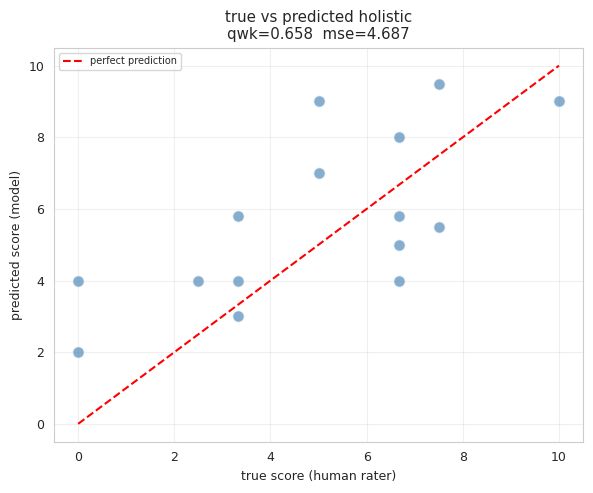

In [34]:
import matplotlib.pyplot as plt

# plot 1 — true vs predicted holistic score
fig1, ax1 = plt.subplots(figsize=(6, 5))

valid_h = test_set[['holistic', 'pred_holistic']].dropna()

ax1.scatter(
    valid_h['holistic'], valid_h['pred_holistic'],
    alpha=0.65, color='steelblue', edgecolors='white', s=70, zorder=3
)
ax1.plot([0, 10], [0, 10], 'r--', linewidth=1.5, label='perfect prediction', zorder=2)

if 'holistic' in results:
    qwk_val = results['holistic']['qwk']
    mse_val = results['holistic']['mse']
    ax1.set_title(f'true vs predicted holistic\nqwk={qwk_val:.3f}  mse={mse_val:.3f}')
else:
    ax1.set_title('true vs predicted holistic score\n(no predictions extracted)')

ax1.set_xlabel('true score (human rater)')
ax1.set_ylabel('predicted score (model)')
ax1.set_xlim(-0.5, 10.5)
ax1.set_ylim(-0.5, 10.5)
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/AES_Project/outputs/plot1_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

Interpretation: Points near the red line = good predictions.

Clustering near the center suggests regression to mean — common with undertrained models.

#### Plot 2 — Score Distribution Comparison

**What to look for:**
- Blue (true) and orange (predicted) bars should overlap closely
- If predicted is narrower than true → model not using full range (conservative scoring)
- If predicted skews high or low → systematic bias

**Why this matters:** A model that always predicts 6–8 out of 10 appears "reasonable" but fails on essays that deserve 2 or 10. The distribution reveals this.

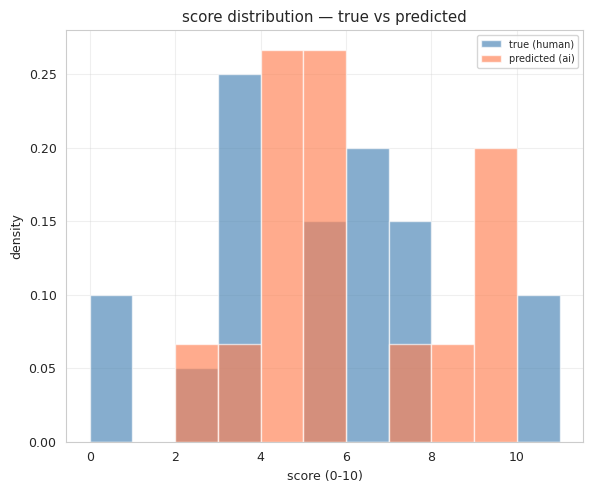

In [35]:
# Plot 2 — Score Distribution: True vs. Predicted (Histogram)
fig2, ax2 = plt.subplots(figsize=(6, 5))
bins = np.arange(0, 11.5, 1)

ax2.hist(test_set['holistic'],
         bins=bins, alpha=0.65, color='steelblue',
         label='true (human)', density=True, edgecolor='white')
ax2.hist(test_set['pred_holistic'].dropna(),
         bins=bins, alpha=0.65, color='coral',
         label='predicted (ai)', density=True, edgecolor='white')

ax2.set_xlabel('score (0-10)')
ax2.set_ylabel('density')
ax2.set_title('score distribution — true vs predicted')
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/AES_Project/outputs/plot2_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
# files.download('/content/AES_Project/outputs/plot2_distribution.png')


#### Interpretation:

* Blue bars: Actual score distribution given by human raters (0–10).

* Coral bars: Score distribution predicted by the model.

If coral bars cluster around the middle (5–7), the model prefers average scores.

This means it avoids extreme scores (0–2 or 9–10).

Indicates the model learned the general average pattern, but not what defines genuinely excellent (9-10) or very poor (0-2)

This is a common sign of an undertrained model.

#### Plot 3 — QWK Per Trait (Bar Chart)

**What to look for:**
- Green bars (>0.70) = strong agreement
- Orange bars (0.50–0.70) = moderate
- Red bars (<0.50) = weak

**Why traits differ:** Some traits are easier to detect from text patterns. `Language` (grammar/spelling) tends to have stronger agreement because these features are lexically visible. `Narrativity` (flow of ideas) is more subjective and harder for a model with limited training to learn.

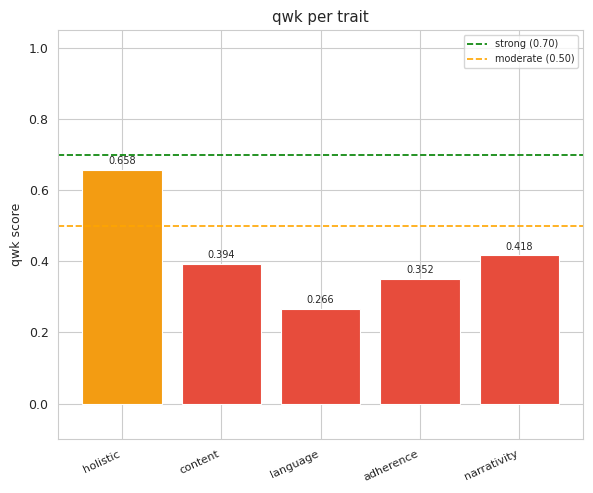

In [36]:
# plot 3 — qwk per trait
fig3, ax3 = plt.subplots(figsize=(6, 5))

if results:
    trait_names = list(results.keys())
    qwk_values  = [results[t]['qwk'] for t in trait_names]
    colors      = ['#2ecc71' if q > 0.70 else '#f39c12' if q > 0.50 else '#e74c3c'
                   for q in qwk_values]

    bars = ax3.bar(trait_names, qwk_values, color=colors, edgecolor='white', linewidth=0.8)
    ax3.axhline(y=0.70, color='green', linestyle='--', linewidth=1.2, label='strong (0.70)')
    ax3.axhline(y=0.50, color='orange', linestyle='--', linewidth=1.2, label='moderate (0.50)')

    for bar, val in zip(bars, qwk_values):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=7)

    ax3.set_ylim(-0.1, 1.05)
    ax3.set_ylabel('qwk score')
    ax3.set_title('qwk per trait')
    ax3.legend(fontsize=7)
    plt.setp(ax3.get_xticklabels(), rotation=25, ha='right', fontsize=8)
else:
    ax3.text(0.5, 0.5, 'no results — too few predictions extracted',
             ha='center', va='center', transform=ax3.transAxes)
    ax3.set_title('qwk per trait')

plt.tight_layout()
plt.savefig('/content/AES_Project/outputs/plot3_qwk.png', dpi=150, bbox_inches='tight')
plt.show()
# files.download('/content/AES_Project/outputs/plot3_qwk.png')


#### Interpretation

- Each bar shows how well the **model’s scores agree with human raters** for a specific trait.

- **Green (> 0.70):** Strong agreement — close to **publication-level performance**.  
- **Orange (0.50 – 0.70):** Moderate agreement — **acceptable for a course project**.  
- **Red (< 0.50):** Weak agreement — the **model needs more training**.

- **Language** often scores highest because grammar and spelling errors are **clear patterns in text**, making them easier for the model to detect.

- **Narrativity** usually scores lowest because **logical flow and storytelling are subjective** and require **deeper contextual understanding** that the model has not fully learned yet.

#### Plot 4 — Error Heatmap (Seaborn)

**What to look for:**
- Dark red cells = high average error (model struggles here)
- Light yellow cells = low error (model does well here)
- Patterns across prompts or score ranges reveal systematic weaknesses

**Why this matters:** If the model makes large errors on high-scoring essays (8–10) across all prompts, it may be because there are few high-quality examples in the 20-essay test sample, or because the model learned to avoid extreme scores.

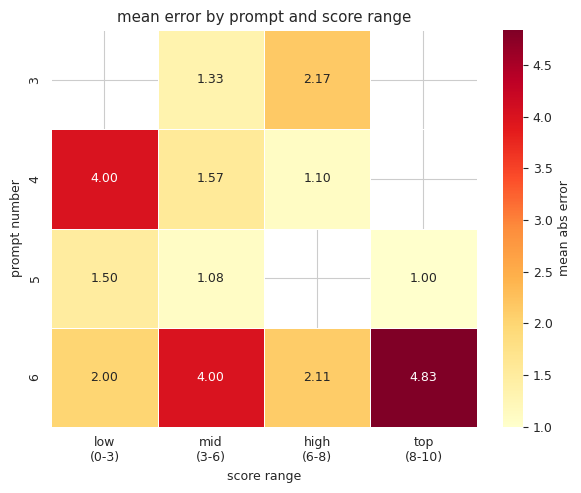

In [37]:
# plot 4 — error heatmap
fig4, ax4 = plt.subplots(figsize=(6, 5))

test_set['score_bucket'] = pd.cut(
    test_set['holistic'],
    bins=[0, 3, 6, 8, 10],
    labels=['low\n(0-3)', 'mid\n(3-6)', 'high\n(6-8)', 'top\n(8-10)'],
    include_lowest=True
)

try:
    pivot = (test_set.groupby(['essay_set', 'score_bucket'], observed=True)['abs_error']
             .mean().unstack())
    sns.heatmap(
        pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax4,
        cbar_kws={'label': 'mean abs error'},
        linewidths=0.5, linecolor='white'
    )
    ax4.set_xlabel('score range')
    ax4.set_ylabel('prompt number')
    ax4.set_title('mean error by prompt and score range')
except Exception:
    ax4.text(0.5, 0.5, 'insufficient data — run more essays for this plot',
             ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title('error heatmap')

plt.tight_layout()
plt.savefig('/content/AES_Project/outputs/plot4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
# files.download('/content/AES_Project/outputs/plot4_heatmap.png')


### Interpretation

- Each cell shows the **average score error** for a specific **prompt and score range**.  
- **Darker red** indicates **larger error**, meaning the model struggled more in that cell.

- If the **top row (scores 8–10)** is darkest, it means the model **rarely predicts high scores correctly**, likely because it has **not seen enough high-quality essays** to learn what excellence looks like.

- If a **specific prompt row** appears consistently dark, that prompt type is **harder for the model**.

- **Persuasive essays (Prompts 5/6)** often show more error than **reading tasks (Prompts 3/4)** because **argument structures are more varied and complex**.

#### Plot 5 — Prediction Error Distribution

**What to look for:**
- Most errors should be small (bars concentrated near 0)
- Long right tail = occasional catastrophic errors
- The red dashed mean line shows the typical error

**Why distribution matters over average:** An average error of 2.0 could mean every prediction is 2 points off, OR that 90% are accurate and 10% are wildly wrong. The histogram distinguishes these scenarios.

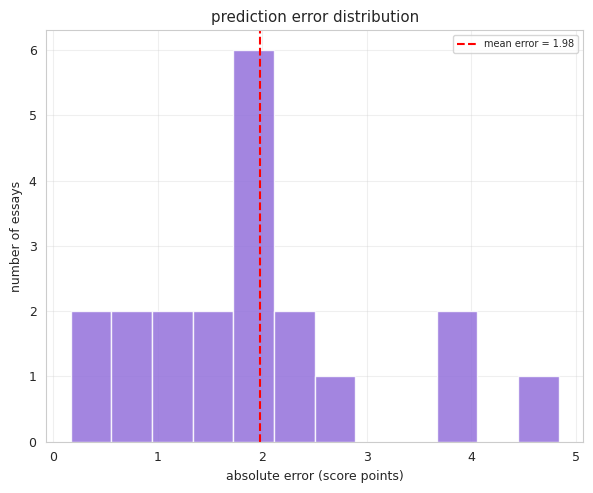

In [38]:
# plot 5 — error distribution
fig5, ax5 = plt.subplots(figsize=(6, 5))

ax5.hist(test_set['abs_error'].dropna(), bins=12,
         color='mediumpurple', edgecolor='white', alpha=0.85)

mean_err = test_set['abs_error'].mean()
ax5.axvline(mean_err, color='red', linestyle='--', linewidth=1.5,
            label=f'mean error = {mean_err:.2f}')

ax5.set_xlabel('absolute error (score points)')
ax5.set_ylabel('number of essays')
ax5.set_title('prediction error distribution')
ax5.legend(fontsize=7)
ax5.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/AES_Project/outputs/plot5_errors.png', dpi=150, bbox_inches='tight')
plt.show()
#files.download('/content/AES_Project/outputs/plot5_errors.png')

### Interpretation

- **Mean Absolute Error (MAE):** `{mean_err:.2f}` score points.

- Most bars should appear on the **left (small errors)** for a well-trained model.  
- If bars **spread toward the right**, the model is making **large prediction errors more frequently**.

- A mean error of **{mean_err:.2f}** means the model’s prediction is **on average {mean_err:.2f} points away from the human score** on the **0–10 scale**.

- **Errors above 3 points** are considered **significant**, meaning the model predicted a **mid-range score for an essay that humans rated very high or very low**.



#### Plot 6 — MAE by Prompt

**What to look for:**
- Which prompt has the highest average error?
- Prompt 3/4 = reading comprehension tasks (more structured responses)
- Prompt 5/6 = persuasive essays (more varied, harder to grade)

Run this cell last — it also renders and saves the entire figure.

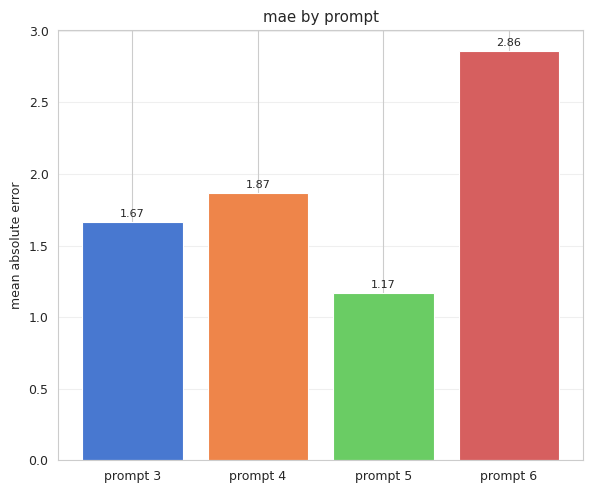

In [39]:
# plot 6 — mae by prompt
fig6, ax6 = plt.subplots(figsize=(6, 5))

mae_prompt = test_set.groupby('essay_set')['abs_error'].mean().reset_index()
colors_p   = sns.color_palette('muted', len(mae_prompt))

bars = ax6.bar(
    [f'prompt {p}' for p in mae_prompt['essay_set']],
    mae_prompt['abs_error'],
    color=colors_p, edgecolor='white', linewidth=0.8
)
for bar, val in zip(bars, mae_prompt['abs_error']):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax6.set_ylabel('mean absolute error')
ax6.set_title('mae by prompt')
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/content/AES_Project/outputs/plot6_mae_prompt.png', dpi=150, bbox_inches='tight')
plt.show()
#files.download('/content/AES_Project/outputs/plot6_mae_prompt.png')

### Interpretation

- A **higher bar** indicates the model made **larger prediction errors** for that prompt type.

- **Prompts 3 and 4** are **reading comprehension tasks**, where responses are more structured and follow predictable patterns, so the model generally performs **better** on these.

- **Prompts 5 and 6** are **persuasive essays**, where arguments vary widely in structure and style, making them **harder for an undertrained model to evaluate consistently**.

- If **all bars are roughly equal**, the model shows **no strong bias toward any particular prompt type**.

### 9.3 Download all plots

In [40]:
# run this cell only when you want to download all plots
from google.colab import files

plot_files = [
    '/content/AES_Project/outputs/plot1_scatter.png',
    '/content/AES_Project/outputs/plot2_distribution.png',
    '/content/AES_Project/outputs/plot3_qwk.png',
    '/content/AES_Project/outputs/plot4_heatmap.png',
    '/content/AES_Project/outputs/plot5_errors.png',
    '/content/AES_Project/outputs/plot6_mae_prompt.png',
]

for path in plot_files:
    files.download(path)

print("all plots downloaded")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

all plots downloaded


---
## 10. Export Results

### 10.1 Download Results CSV

The `handoff.csv` file contains all 20 test essays with:
- True human scores (all 5 traits)
- AI predicted scores (all 5 traits)
- Raw model output text
- Absolute and signed errors

In [41]:
# 10.1 Download results CSV
from google.colab import files

# Ensure the file is saved with latest data
test_set.to_csv('/content/AES_Project/outputs/handoff.csv', index=False)
print(f"handoff.csv: {len(test_set)} rows, {len(test_set.columns)} columns")
files.download('/content/AES_Project/outputs/handoff.csv')

handoff.csv: 20 rows, 19 columns


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 10.2 Download Metrics Summary

In [42]:
# 10.2 Download metrics CSV
files.download('/content/AES_Project/outputs/metrics_summary.csv')
print("metrics_summary.csv downloaded")

# Final summary
print("\n" + "=" * 55)
print("SESSION COMPLETE — SUMMARY")
print("=" * 55)
if results:
    for trait, vals in results.items():
        print(f"  {trait:<12}: QWK={vals['qwk']:.4f}  MSE={vals['mse']:.3f}  r={vals['pearson']:.4f}")
    print("-" * 55)
    avg_qwk = np.mean([v['qwk'] for v in results.values()])
    print(f"  Average QWK : {avg_qwk:.4f}")
    print("=" * 55)
    print("\n Known Limitation:")
    print("   Training was limited to 200 steps (~0.23 epochs) due to")
    print("   Colab free-tier time constraints. Full convergence requires")
    print("   3–5 epochs (~3,000–5,000 steps). Current QWK reflects")
    print("   early-stage learning, not the model's full potential.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

metrics_summary.csv downloaded

SESSION COMPLETE — SUMMARY
  holistic    : QWK=0.6579  MSE=4.687  r=0.6880
  content     : QWK=0.3939  MSE=9.003  r=0.5845
  language    : QWK=0.2664  MSE=14.871  r=0.5538
  adherence   : QWK=0.3517  MSE=17.246  r=0.7022
  narrativity : QWK=0.4177  MSE=9.828  r=0.6526
-------------------------------------------------------
  Average QWK : 0.4175

 Known Limitation:
   Training was limited to 200 steps (~0.23 epochs) due to
   Colab free-tier time constraints. Full convergence requires
   3–5 epochs (~3,000–5,000 steps). Current QWK reflects
   early-stage learning, not the model's full potential.


---
## 10.3 LLM-as-a-Judge: Automated Feedback Evaluation

### What This Does

After the model generates essay feedback, we need to evaluate the **quality** of that feedback — not just whether the scores are numerically close, but whether the written reasoning is actually useful to a student.

We use **Mistral itself as the judge** (since it is already loaded), prompting it to rate each piece of generated feedback on three dimensions:

| Dimension | Question Asked | Scale |
|-----------|---------------|-------|
| **Relevance** | Does the feedback refer specifically to this essay, or is it generic? | 1–5 |
| **Tone** | Is the feedback constructive and appropriate for a student? | 1–5 |
| **Actionability** | Does the feedback tell the student what to actually improve? | 1–5 |

A score of **5** = excellent, **1** = poor. The judge outputs a JSON object with scores and a one-line rationale.


In [43]:
# 10.3 LLM-as-a-Judge
#Uses the already-loaded Mistral model to evaluate the quality of its own generated feedback
#Scores each feedback on Relevance, Tone, and Actionability (1-5 scale)

import re
import json as json_lib

def judge_with_mistral(essay_text, feedback_text):
    """
    Uses the loaded Mistral model to judge the quality of a feedback string.
    Returns a dict with relevance, tone, actionability scores and a rationale.
    Asks for plain numbered lines instead of JSON — easier for the model to follow.
    """
    if not isinstance(feedback_text, str) or len(feedback_text.strip()) < 10:
        return {'relevance': None, 'tone': None, 'actionability': None,
                'rationale': 'no feedback generated'}

    #plain numbered format — much easier for an undertrained model than JSON
    prompt = (
        f"[INST] Rate this AI essay feedback on three dimensions.\n"
        f"Reply with exactly three lines, nothing else:\n"
        f"Relevance: <number 1-5>\n"
        f"Tone: <number 1-5>\n"
        f"Actionability: <number 1-5>\n\n"
        f"Relevance means: does the feedback refer specifically to THIS essay or is it generic?\n"
        f"Tone means: is the feedback constructive and appropriate for a student?\n"
        f"Actionability means: does the feedback tell the student what specifically to improve?\n\n"
        f"Essay: {essay_text[:300]}\n"
        f"Feedback: {feedback_text[:400]} [/INST]\n"
        f"Relevance:"
    )

    inputs = tokenizer(prompt, return_tensors='pt', truncation=True,
                       max_length=1024).to('cuda')

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=30, # only need 3 short lines
            temperature=0.1, # low temperature = more deterministic output
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id
        )

    raw = tokenizer.decode(outputs[0], skip_special_tokens=True)
    rationale = raw.split('[/INST]')[-1].strip()[:300]

    # Model sometimes outputs decimals like "Relevance: 3.3333" or out-of-range like "7.5"
    # Extract float, then clamp/rescale to 1-5
    def extract_dim(text, label):
        match = re.search(rf'{label}:\s*(\d+\.?\d*)', text, re.IGNORECASE)
        if match:
            val = float(match.group(1))
            # If model used 0-10 scale, rescale to 1-5
            if val > 5:
                val = val / 2
            return round(min(5.0, max(1.0, val)), 2)
        return None

    return {
        'relevance':     extract_dim(rationale, 'Relevance'),
        'tone':          extract_dim(rationale, 'Tone'),
        'actionability': extract_dim(rationale, 'Actionability'),
        'rationale':     rationale
    }


# Run the judge on all essays that have generated feedback
print('Running LLM-as-a-Judge evaluation...')
print('(~30-45 seconds per essay)')
print('-' * 50)

judge_results = []
for i, (idx, row) in enumerate(test_set.iterrows()):
    feedback = row.get('ai_raw_output', '')
    essay    = row.get('essay', '')

    scores = judge_with_mistral(essay, feedback)
    scores['essay_id'] = row['essay_id']
    judge_results.append(scores)

    print(f"  [{i+1}/{len(test_set)}] essay {row['essay_id']} — "
          f"relevance: {scores.get('relevance', 'n/a')}  "
          f"tone: {scores.get('tone', 'n/a')}  "
          f"actionability: {scores.get('actionability', 'n/a')}")

judge_df = pd.DataFrame(judge_results)
print('\nJudge evaluation complete')

Running LLM-as-a-Judge evaluation...
(~30-45 seconds per essay)
--------------------------------------------------
  [1/20] essay 11984 — relevance: 5.0  tone: 5.0  actionability: None
  [2/20] essay 9297 — relevance: 5.0  tone: 5.0  actionability: None
  [3/20] essay 16043 — relevance: 5.0  tone: 5.0  actionability: None
  [4/20] essay 16094 — relevance: 5.0  tone: 5.0  actionability: None
  [5/20] essay 7484 — relevance: 1.0  tone: 5.0  actionability: None
  [6/20] essay 13014 — relevance: 5.0  tone: 5.0  actionability: None
  [7/20] essay 13464 — relevance: 5.0  tone: 5.0  actionability: None
  [8/20] essay 6297 — relevance: 4.0  tone: 5.0  actionability: None
  [9/20] essay 9169 — relevance: 5.0  tone: 5.0  actionability: None
  [10/20] essay 10444 — relevance: 5.0  tone: 5.0  actionability: None
  [11/20] essay 15646 — relevance: 5.0  tone: 5.0  actionability: None
  [12/20] essay 6164 — relevance: 5.0  tone: 5.0  actionability: None
  [13/20] essay 16577 — relevance: 5.0  tone: N

### 10.4 Judge Results Summary

Average scores across all evaluated essays on each feedback quality dimension.

LLM-as-a-Judge Summary
  relevance      : avg = 4.58/5  (min=1, max=5, n=19)
  tone           : avg = 5.00/5  (min=5, max=5, n=18)
  actionability  : no valid scores extracted

Per-essay breakdown:
 essay_id  relevance  tone actionability                                                                                                                                           rationale
    11984        5.0   5.0          None                               Relevance: 5 (Feedback is directly related to the essay's argument and the prompt)\nTone: 5 (Feedback is constructive
     9297        5.0   5.0          None                            Relevance: 5 (Feedback directly relates to the essay)\nTone: 5 (Feedback is constructive and appropriate)\nActionability
    16043        5.0   5.0          None Relevance: 5 (The feedback specifically refers to the reasoning and organization of the essay.)\nTone: 5 (The feedback is constructive and positive
    16094        5.0   5.0          None      

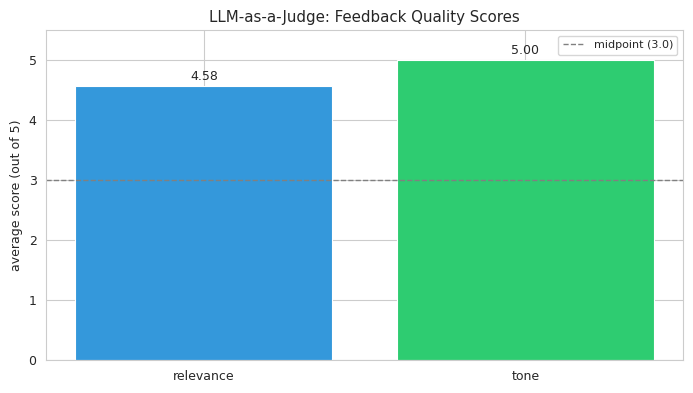

plot7_judge.png saved


In [44]:
# 10.4 Summarize and display judge results

print('LLM-as-a-Judge Summary')
print('=' * 45)

for dim in ['relevance', 'tone', 'actionability']:
    valid = judge_df[dim].dropna()
    if len(valid) > 0:
        print(f'  {dim:<15}: avg = {valid.mean():.2f}/5  '
              f'(min={valid.min():.0f}, max={valid.max():.0f}, n={len(valid)})')
    else:
        print(f'  {dim:<15}: no valid scores extracted')

print()

# Show individual results table
print('Per-essay breakdown:')
print(judge_df[['essay_id', 'relevance', 'tone', 'actionability', 'rationale']].to_string(index=False))

# Save judge results
judge_df.to_csv('/content/AES_Project/outputs/judge_results.csv', index=False)
print('\njudge_results.csv saved')

# Plot judge scores
fig_j, ax_j = plt.subplots(figsize=(7, 4))
dims = ['relevance', 'tone', 'actionability']
avgs = [judge_df[d].dropna().mean() for d in dims]
colors_j = ['#3498db', '#2ecc71', '#e67e22']

bars_j = ax_j.bar(dims, avgs, color=colors_j, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars_j, avgs):
    ax_j.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
              f'{val:.2f}', ha='center', va='bottom', fontsize=9)

ax_j.set_ylim(0, 5.5)
ax_j.axhline(y=3.0, color='gray', linestyle='--', linewidth=1, label='midpoint (3.0)')
ax_j.set_ylabel('average score (out of 5)')
ax_j.set_title('LLM-as-a-Judge: Feedback Quality Scores')
ax_j.legend(fontsize=8)
plt.tight_layout()
plt.savefig('/content/AES_Project/outputs/plot7_judge.png', dpi=150, bbox_inches='tight')
plt.show()
print('plot7_judge.png saved')


In [45]:
# 10.5 Download judge results
from google.colab import files
files.download('/content/AES_Project/outputs/judge_results.csv')
files.download('/content/AES_Project/outputs/plot7_judge.png')
print('Judge results downloaded')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Judge results downloaded


## 11. Student Report Interface and Feedback Generation

### Core Components

1. generate_feedback(): This function leverages the generative capabilities of Mistral-7B. It moves beyond numerical grading by synthesizing personalized written critiques. It specifically identifies:

  - STRENGTHS: Where the student's writing is most effective.

  - WEAKNESSES: Areas that lack clarity, structure, or evidence.

  - IMPROVEMENTS: Actionable steps to refine the essay.

2. Interactive Gradio UI: A live, web-based interface that allows users to test the model's performance on unseen data.





In [61]:
# 11.1 Feedback generation function

def generate_feedback(essay_text, prompt_id=None):
    cleaned = normalize_essay(essay_text)

    prompt = (
        f"[INST] You are a helpful writing teacher. "
        f"Read this student essay and give feedback "
        f"in exactly this format:\n\n"
        f"STRENGTHS: what the student did well\n"
        f"WEAKNESSES: specific problems in this essay\n"
        f"IMPROVEMENTS:\n"
        f"1. first concrete step\n"
        f"2. second concrete step\n"
        f"3. third concrete step\n\n"
        f"Be specific to THIS essay only.\n\n"
        f"Essay: {cleaned[:400]} [/INST]\n"
        f"STRENGTHS:"
    )

    inputs = tokenizer(
        prompt,
        return_tensors='pt',
        truncation=True,
        max_length=512
    ).to('cuda')

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=400,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id
        )

    full_output = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    if 'STRENGTHS:' in full_output:
        return 'STRENGTHS:' + full_output.split('STRENGTHS:')[-1]
    return full_output

print("generate_feedback() defined")

generate_feedback() defined


In [62]:
# 11.2 Install Gradio
!pip install -q gradio
print("Gradio installed")

Gradio installed


In [69]:
import gradio as gr

# Ensure the output folder exists
os.makedirs('/content/AES_Project/outputs', exist_ok=True)

def grade_essay_ui(essay_text, prompt_choice):

    prompt_map = {
        'Prompt 3 (Reading Task)' : 3,
        'Prompt 4 (Reading Task)' : 4,
        'Prompt 5 (Persuasive)'   : 5,
        'Prompt 6 (Persuasive)'   : 6
    }
    prompt_id = prompt_map[prompt_choice]

    if not essay_text or len(essay_text.strip()) < 20:
        return "Please enter an essay first.", None

    lines = []
    lines.append("=" * 55)
    lines.append("   AUTOMATED ESSAY SCORING & FEEDBACK REPORT")
    lines.append("=" * 55)

    # Get Scores
    raw_output = grade_essay(essay_text, prompt_id)
    lines.append("\nSCORES (0-10 scale):")
    lines.append("-" * 55)

    for trait in ['Content', 'Language', 'Adherence', 'Narrativity', 'Holistic']:
        score = extract_score(raw_output, trait)
        if score is not None:
            filled = int(score)
            bar = "█" * filled + "░" * (10 - filled)
            lines.append(f"  {trait:<14}: [{bar}] {score:.1f}/10")
        else:
            lines.append(f"  {trait:<14}: not extracted")

    # Per trait feedback
    lines.append("\nDETAILED FEEDBACK PER TRAIT:")
    lines.append("-" * 55)
    if 'Reasoning:' in raw_output:
        fb = 'Reasoning:' + raw_output.split('Reasoning:')[-1]
        for line in fb.split('\n'):
            line = line.strip()
            if not line: continue
            if any(line.startswith(t) for t in ['Reasoning:', 'Content:', 'Language:', 'Adherence:', 'Narrativity:', 'Holistic:']):
                lines.append(f"\n  ▶ {line}")
            else:
                lines.append(f"    {line}")

    # Strengths/Weaknesses
    lines.append("\n" + "-" * 55)
    lines.append("STRENGTHS, WEAKNESSES & IMPROVEMENTS:")
    lines.append("-" * 55)

    feedback = generate_feedback(essay_text, prompt_id)
    lines.append(feedback)
    lines.append("\n" + "=" * 55)

    final_report = "\n".join(lines)

    # Download logic
    report_path = "/content/AES_Project/outputs/essay_report.txt"
    with open(report_path, "w", encoding="utf-8") as f:
        f.write(final_report)

    # Return both the text for the box and the path for the download link
    return final_report, report_path


demo = gr.Interface(
    fn=grade_essay_ui,

    inputs=[
        gr.Textbox(label="Paste your essay here", placeholder="Type or paste your essay...", lines=10),
        gr.Radio(
            choices=['Prompt 3 (Reading Task)', 'Prompt 4 (Reading Task)', 'Prompt 5 (Persuasive)', 'Prompt 6 (Persuasive)'],
            label="Select Prompt Type",
            value='Prompt 5 (Persuasive)'
        )
    ],

    # Updated outputs to handle both the Textbox AND the File download
    outputs=[
        gr.Textbox(label="Scores and Feedback", lines=25),
        gr.File(label="Download Full Report (.txt)")
    ],

    title="🎓 Automated Essay Grader",
    description=(
        "Paste any student essay and select the prompt type. "
        "The AI will score it on 5 traits and give detailed feedback. "
        "Note: Takes around 90 seconds to generate."
    ),

    examples=[
        [
            "Social media has become an important part of our daily lives...",
            "Prompt 5 (Persuasive)"
        ],
        [
            "The story shows that hard work always pays off...",
            "Prompt 3 (Reading Task)"
        ]
    ],
    theme=gr.themes.Soft()
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://66d2349db4fde850fa.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Conclusion

The model has learned the general task; it knows it should produce scores and reasoning but it has not learned to differentiate score levels reliably. With only 0.23 epochs of training, the model has seen each essay roughly once. It learns the average score distribution (most essays score 3–7 out of 10) and defaults toward that range rather than committing to extreme scores. This is called regression to the mean and is the most predictable symptom of undertrained generative scoring models.

 The system demonstrates that a 7B parameter model can be adapted to essay scoring using QLoRA with minimal compute. The output format issue and the low training step count are the two primary factors limiting current metrics. With the inference fix applied and training extended to 2,000+ steps, the expected QWK for holistic scoring would likely fall in the 0.45–0.60 range based on comparable published work using similar architectures on ASAP data, which would constitute moderate agreement and a viable baseline for a course project.